In [1]:
def print_portfolio_summary(perf, weights, assets, name):
    """
    Helper function for printing the performance summary of a portfolio.

    Args:
        perf (pd.Series): Series containing the perf metrics
        weights (np.array): An array containing the portfolio weights
        assets (list): list of the asset names
        name (str): the name of the portfolio
    """
    print(f"{name} portfolio ----")
    print("Performance")
    for index, value in perf.items():
        print(f"{index}: {100 * value:.2f}% ", end="", flush=True)
    print("\nWeights")
    for x, y in zip(assets, weights):
        print(f"{x}: {100*y:.2f}% ", end="", flush=True)

In [2]:
# %matplotlib inline
%config InlineBackend.figure_format = "retina"

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

# feel free to modify, for example, change the context to "notebook"
sns.set_theme(context="talk", style="whitegrid",
              palette="colorblind", color_codes=True,
              rc={"figure.figsize": [12, 8]})

## 11.1 Evaluating an equally-weighted portfolio's performance

In [3]:
# 1) Import the libraries:
import yfinance as yf
import numpy as np
import pandas as pd
!pip install quantstats
import quantstats as qs


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 kB 4.2 MB/s eta 0:00:00


[*********************100%***********************]  5 of 5 completed


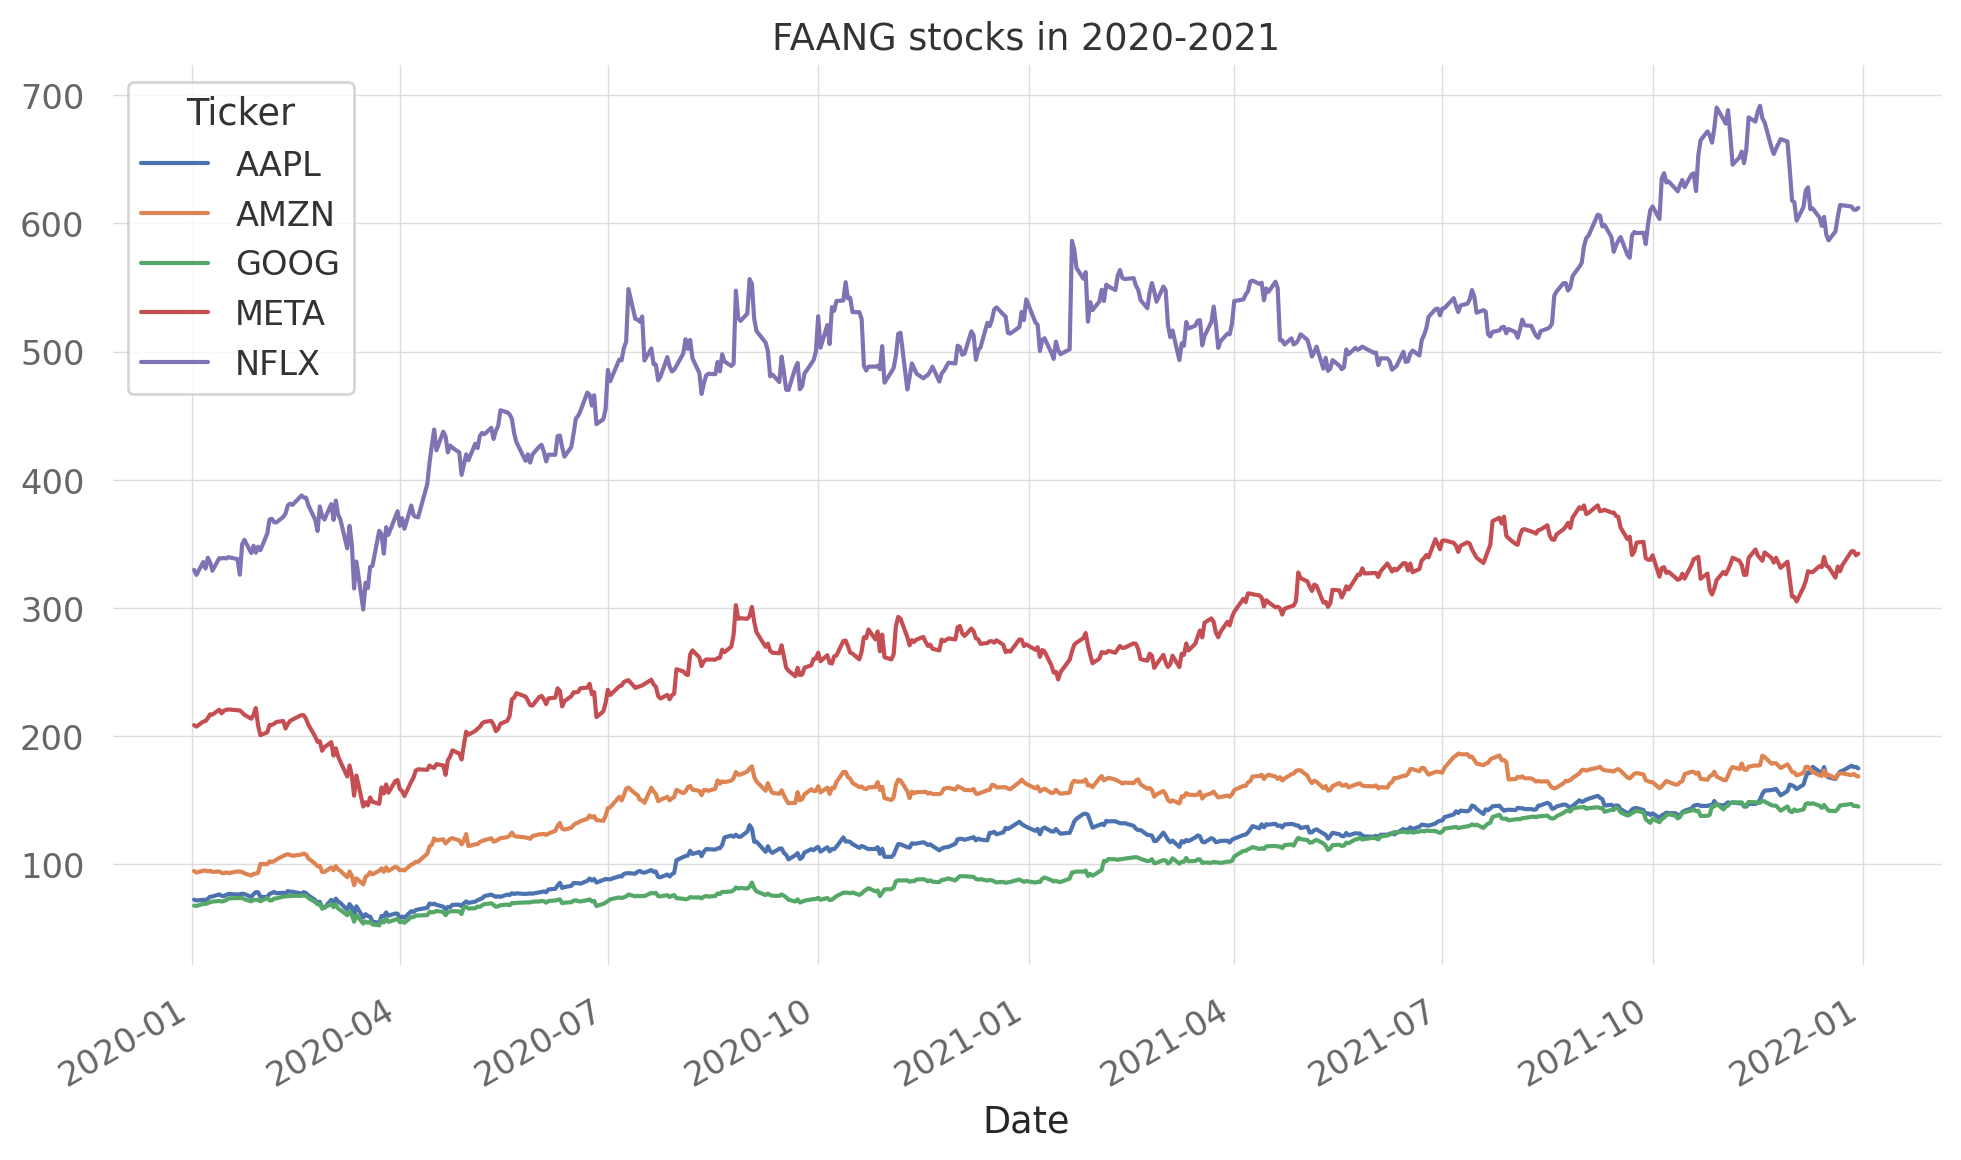

In [4]:
# 2) Define the considered assets and download their prices from Yahoo Finance:
ASSETS = ["META", "AMZN", "AAPL", "NFLX", "GOOG"]
n_assets = len(ASSETS)

prices_df = yf.download(ASSETS, start="2020-01-01", end="2021-12-31")
prices_df["Close"].plot(title="FAANG stocks in 2020-2021")

sns.despine()
plt.tight_layout()

In [5]:
# 3) Calculate individual asset returns:
returns = prices_df["Close"].pct_change().dropna()

In [6]:
# 4) Define the weights
portfolio_weights = n_assets * [1 / n_assets]

In [7]:
# 5) Calculate portfolio returns:
portfolio_returns = pd.Series(np.dot(portfolio_weights, returns.T), index=returns.index)

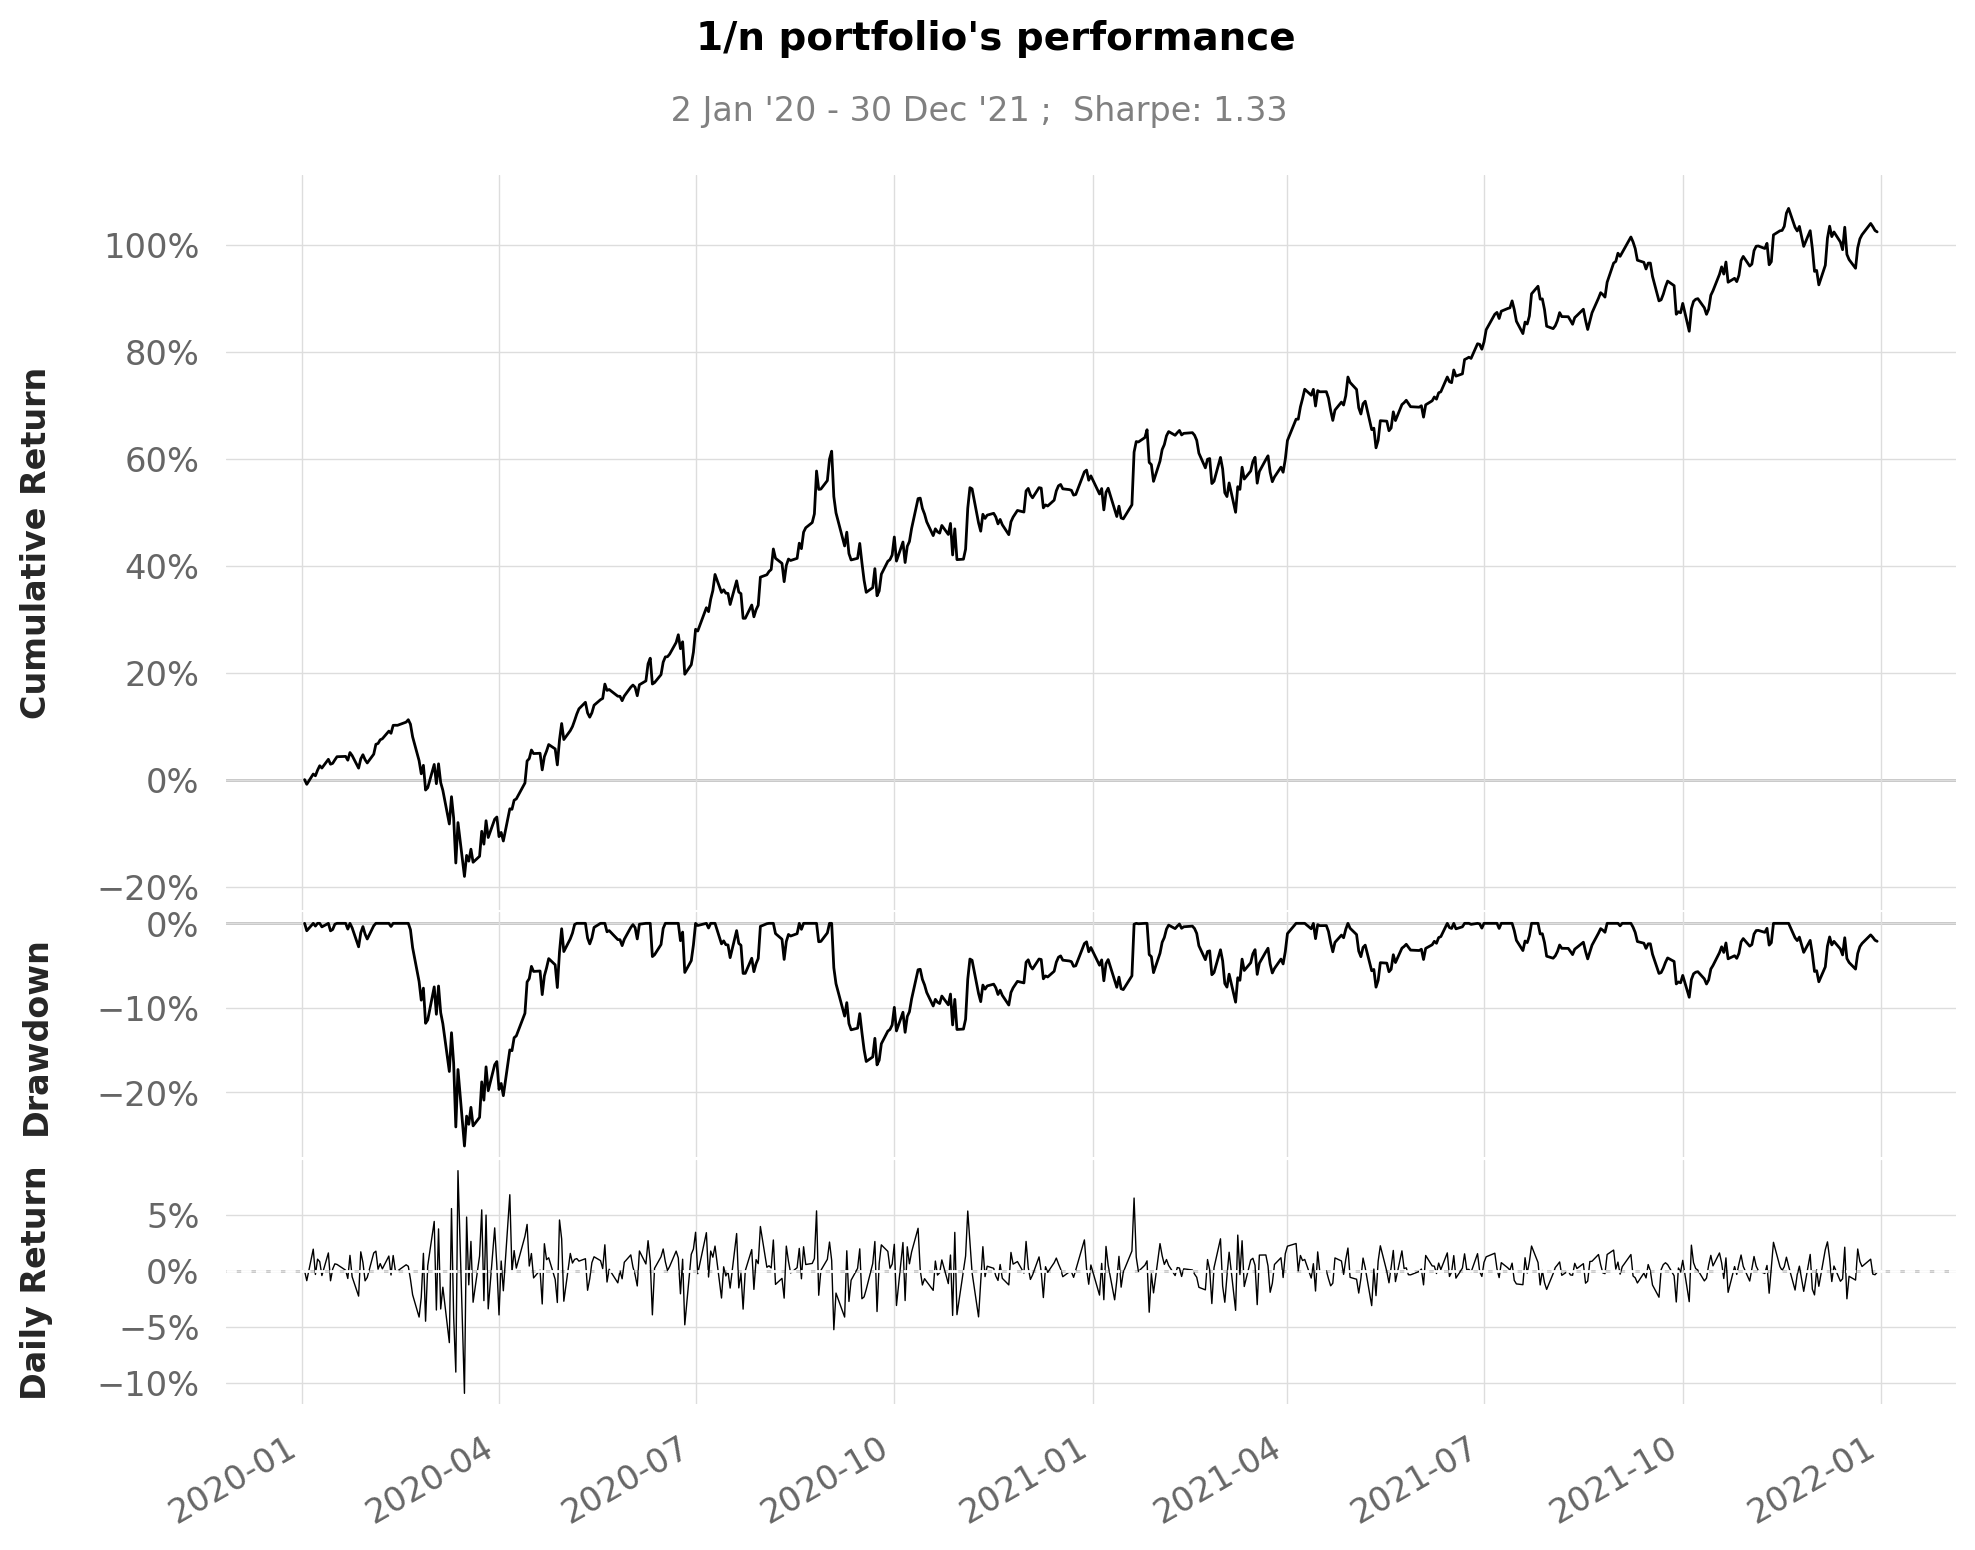

In [8]:
# 6) Generate basic performance evaluation plots:
qs.plots.snapshot(portfolio_returns, title="1/n portfolio's performance", grayscale=True)

In [9]:
# 7) Calculate the basic portfolio evaluation metrics:
qs.reports.metrics(portfolio_returns, benchmark="SPY", mode="basic")

                     Benchmark (SPY)    Strategy
-------------------  -----------------  ----------
Start Period         2020-01-03         2020-01-03
End Period           2021-12-30         2021-12-30
Risk-Free Rate       0.0%               0.0%
Time in Market       100.0%             100.0%

Cumulative Return    52.45%             104.18%
CAGR﹪               15.74%             28.07%

Sharpe               0.96               1.34
Prob. Sharpe Ratio   90.67%             96.83%
Sortino              1.33               1.93
Sortino/√2           0.94               1.36
Omega                1.27               1.27

Max Drawdown         -33.72%            -26.35%
Max DD Date          2020-03-23         2020-03-16
Max DD Period Start  2020-02-20         2020-02-20
Max DD Period End    2020-08-07         2020-05-06
Longest DD Days      170                140

Gain/Pain Ratio      0.22               0.27
Gain/Pain (1M)       1.6                3.42

Payoff Ratio         0.8                0.84


In [10]:
# 8) Generate the full HTML tear sheet:
qs.reports.html(portfolio_returns, benchmark="SPY", title="1/n portfolio",download_filename="EW portfolio evaluation.html", output='notebook')

In [11]:
# 9) Add the methods of quantstats to the pandas DataFrame:
qs.extend_pandas()

In [12]:
# 10) Calculate the Sharpe ratio and the Sortino ratio using the newly added methods:
print(f"Sharpe ratio: {portfolio_returns.sharpe():.2f}")
print(f"Sortino ratio: {portfolio_returns.sortino():.2f}")

Sharpe ratio: 1.33
Sortino ratio: 1.91


In [13]:
# 11) See all the new methods that are available to us thanks to the quantstats library:
[method for method in dir(qs.stats) if method[0] != "_"]

['adjusted_sortino',
 'autocorr_penalty',
 'avg_loss',
 'avg_return',
 'avg_win',
 'best',
 'cagr',
 'calmar',
 'common_sense_ratio',
 'comp',
 'compare',
 'compsum',
 'conditional_value_at_risk',
 'consecutive_losses',
 'consecutive_wins',
 'cpc_index',
 'cvar',
 'distribution',
 'drawdown_details',
 'expected_return',
 'expected_shortfall',
 'exposure',
 'gain_to_pain_ratio',
 'geometric_mean',
 'ghpr',
 'greeks',
 'implied_volatility',
 'information_ratio',
 'kelly_criterion',
 'kurtosis',
 'max_drawdown',
 'monthly_returns',
 'omega',
 'outlier_loss_ratio',
 'outlier_win_ratio',
 'outliers',
 'payoff_ratio',
 'pct_rank',
 'probabilistic_adjusted_sortino_ratio',
 'probabilistic_ratio',
 'probabilistic_sharpe_ratio',
 'probabilistic_sortino_ratio',
 'profit_factor',
 'profit_ratio',
 'r2',
 'r_squared',
 'rar',
 'recovery_factor',
 'remove_outliers',
 'risk_of_ruin',
 'risk_return_ratio',
 'rolling_greeks',
 'rolling_sharpe',
 'rolling_sortino',
 'rolling_volatility',
 'ror',
 'safe_

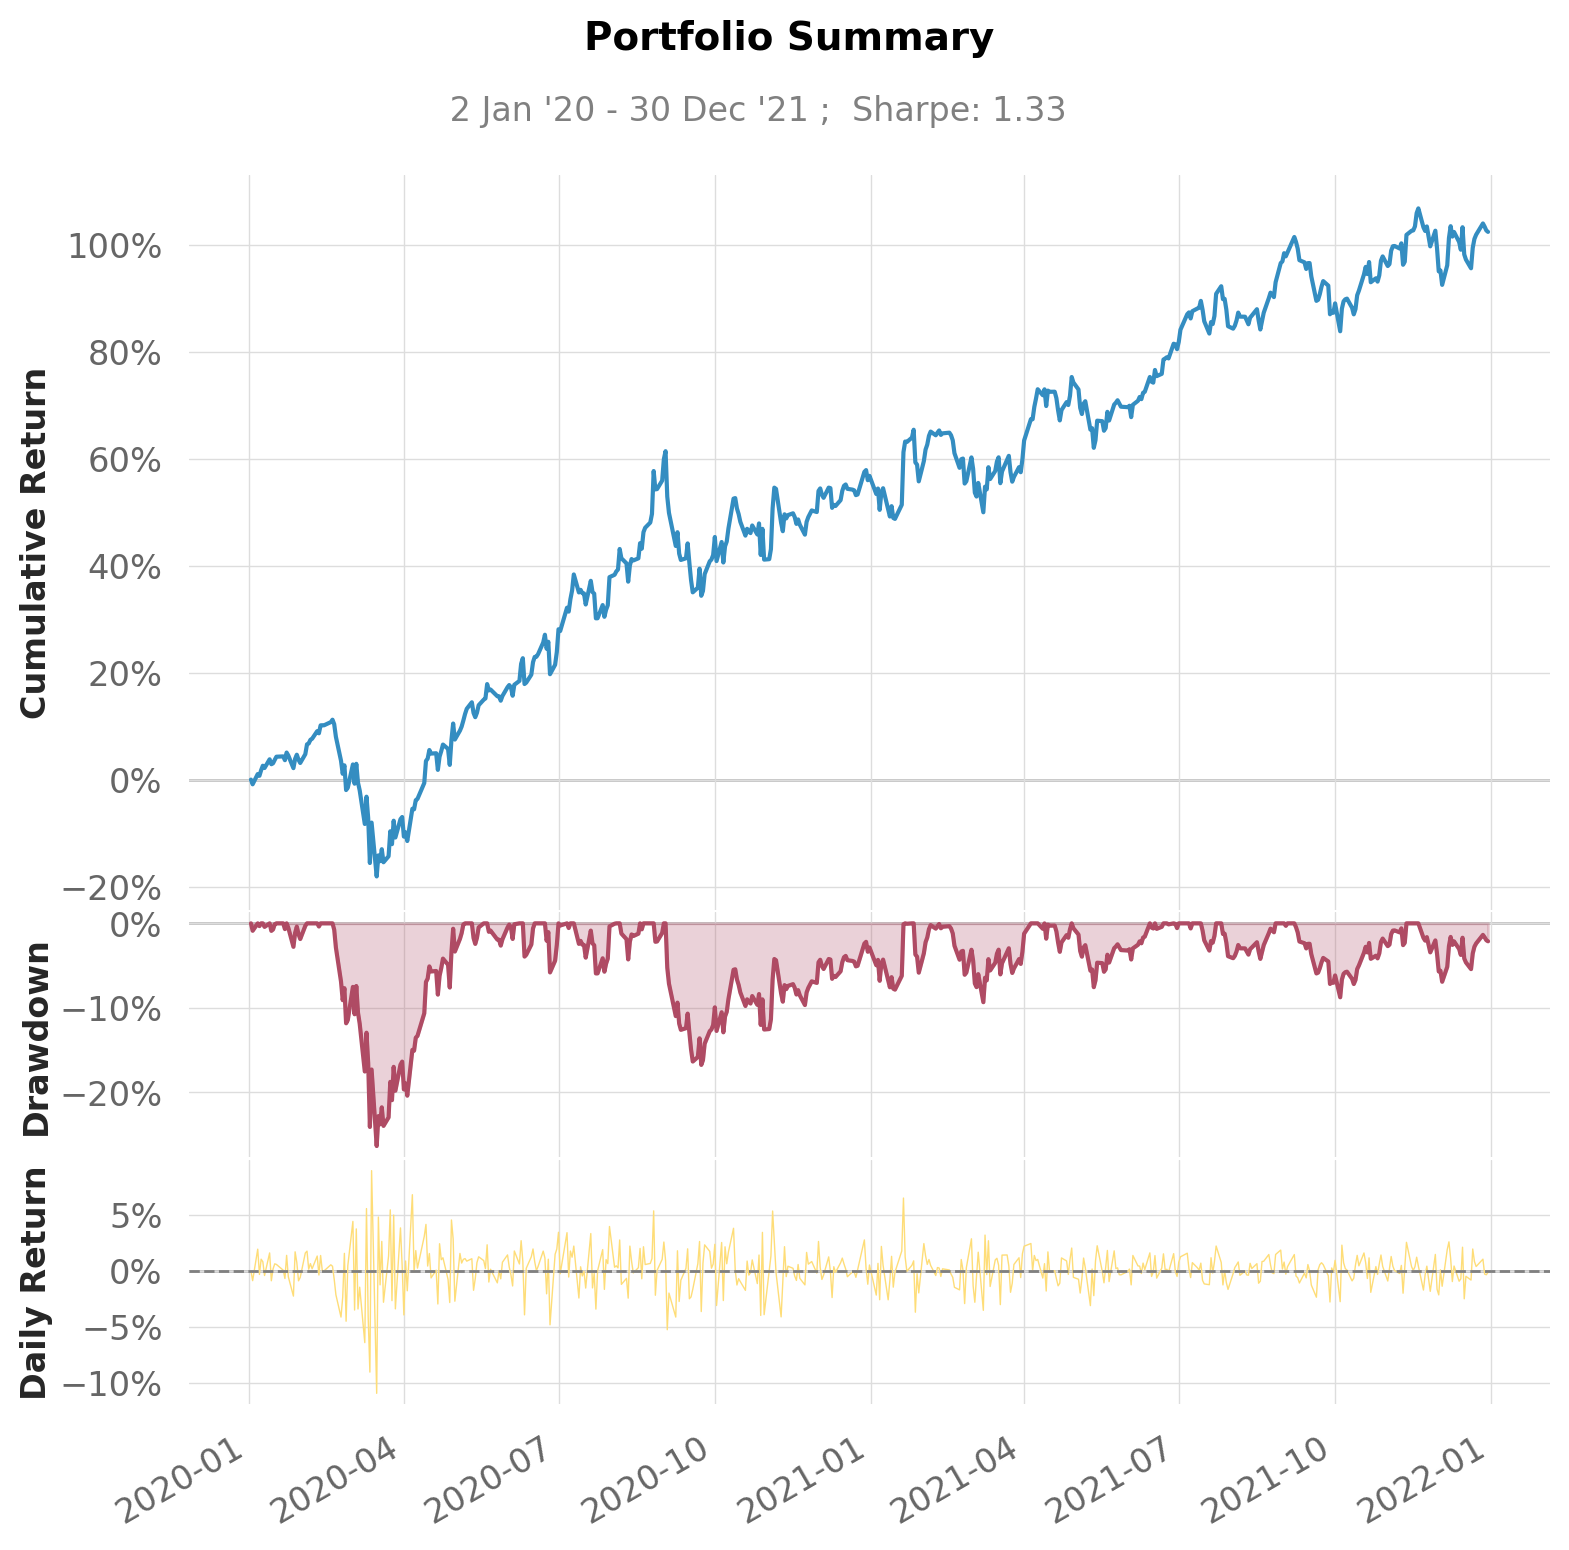

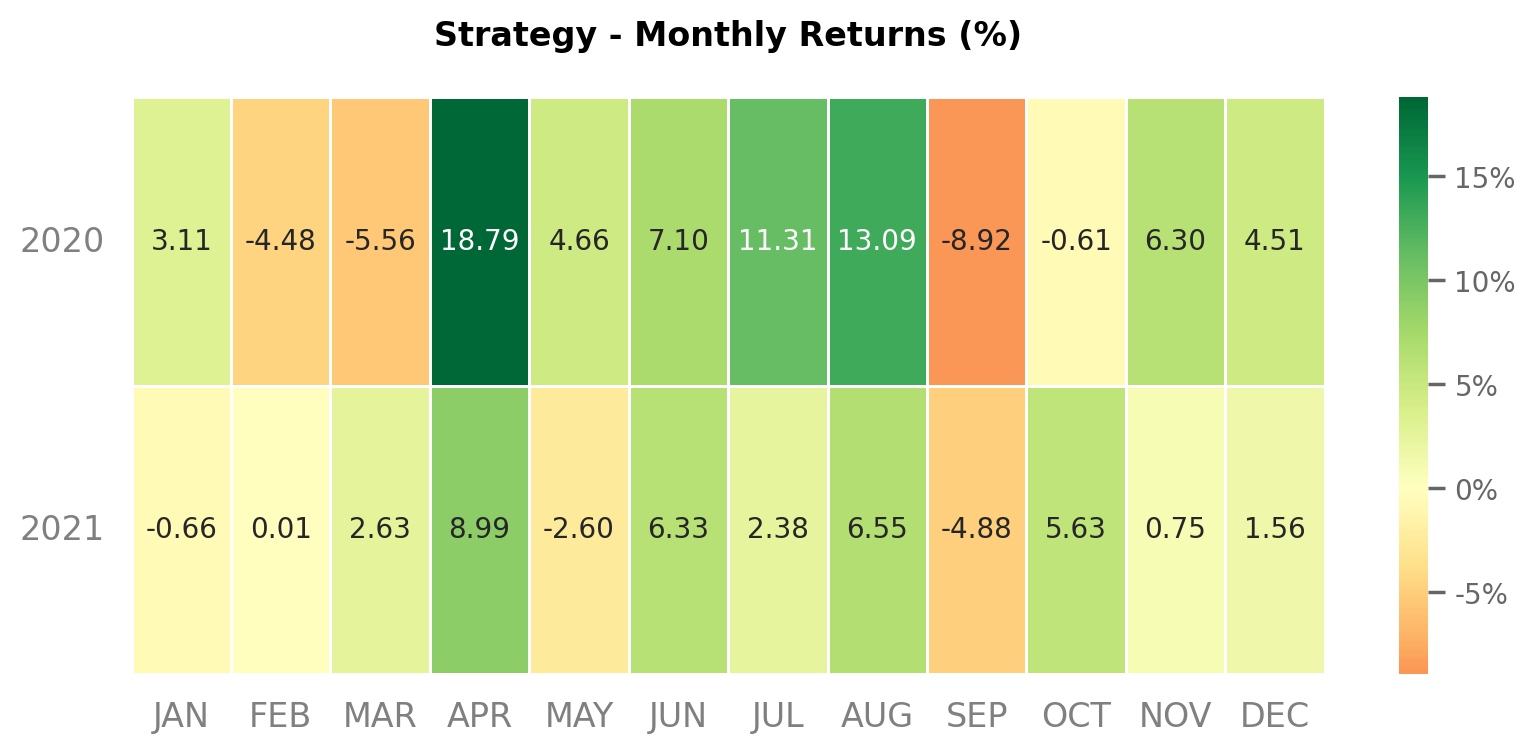

In [14]:
# 12) Generate the plots:
qs.reports.plots(portfolio_returns, benchmark="SPY", mode="basic", prepare_returns=False)
# qs.reports.plots(portfolio_returns, benchmark="SPY", mode="full", prepare_returns=False)

## 11.2 Finding the efficient frontier using Monte Carlo simulations

In [15]:
# 1) Set up the parameters:
N_PORTFOLIOS = 10 ** 5
N_DAYS = 252
ASSETS = ["META", "AMZN", "AAPL", "NFLX", "GOOG"]
ASSETS.sort()

n_assets = len(ASSETS)


In [16]:
# 2) Download the stock prices from Yahoo Finance:
prices_df = yf.download(ASSETS,
                        start="2021-01-01",
                        end="2021-12-31")

[*********************100%***********************]  5 of 5 completed


In [17]:
prices_df.head()

Price            Close                                                 \
Ticker            AAPL        AMZN       GOOG        META        NFLX   
Date                                                                    
2021-01-04  126.239716  159.331497  85.901390  267.472687  522.859985   
2021-01-05  127.800499  160.925507  86.531647  269.491547  520.799988   
2021-01-06  123.498535  156.919006  86.251808  261.873322  500.489990   
2021-01-07  127.712677  158.108002  88.834457  267.273712  508.890015   
2021-01-08  128.815033  159.134995  89.826553  266.110138  510.399994   

Price             High                                                 ...  \
Ticker            AAPL        AMZN       GOOG        META        NFLX  ...   
Date                                                                   ...   
2021-01-04  130.336821  163.600006  87.512313  273.499621  540.799988  ...   
2021-01-05  128.512626  161.169006  86.867154  270.913737  526.780029  ...   
2021-01-06  127.839523  159.875504  86.883551  266.289098  513.099976  ...   
2021-01-07  128.405290  160.427002  88.891613  270.128048  516.440002  ...   
2021-01-08  129.380826  159.531998  89.957277  267.482613  513.239990  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN       GOOG        META        NFLX   
Date                                                                    
2021-01-04  130.249029  163.500000  87.357730  273.280821  539.000000   
2021-01-05  125.732440  158.300507  85.740353  266.826176  521.549988   
2021-01-06  124.591100  157.324005  84.628454  260.570472  511.970001   
2021-01-07  125.215395  157.850006  86.488895  264.449211  508.279999   
2021-01-08  129.185714  159.000000  88.870740  266.846091  511.309998   

Price          Volume                                         
Ticker           AAPL      AMZN      GOOG      META     NFLX  
Date                                                          
2021-01-04  143301900  88228000  38038000  15106100  4444400  
2021-01-05   97664900  53110000  22906000   9871600  3133900  
2021-01-06  155088000  87896000  52042000  24354100  5346200  
2021-01-07  109578200  70290000  45300000  15789800  3686400  
2021-01-08  105158200  70754000  41012000  18528300  2973900  

[5 rows x 25 columns]

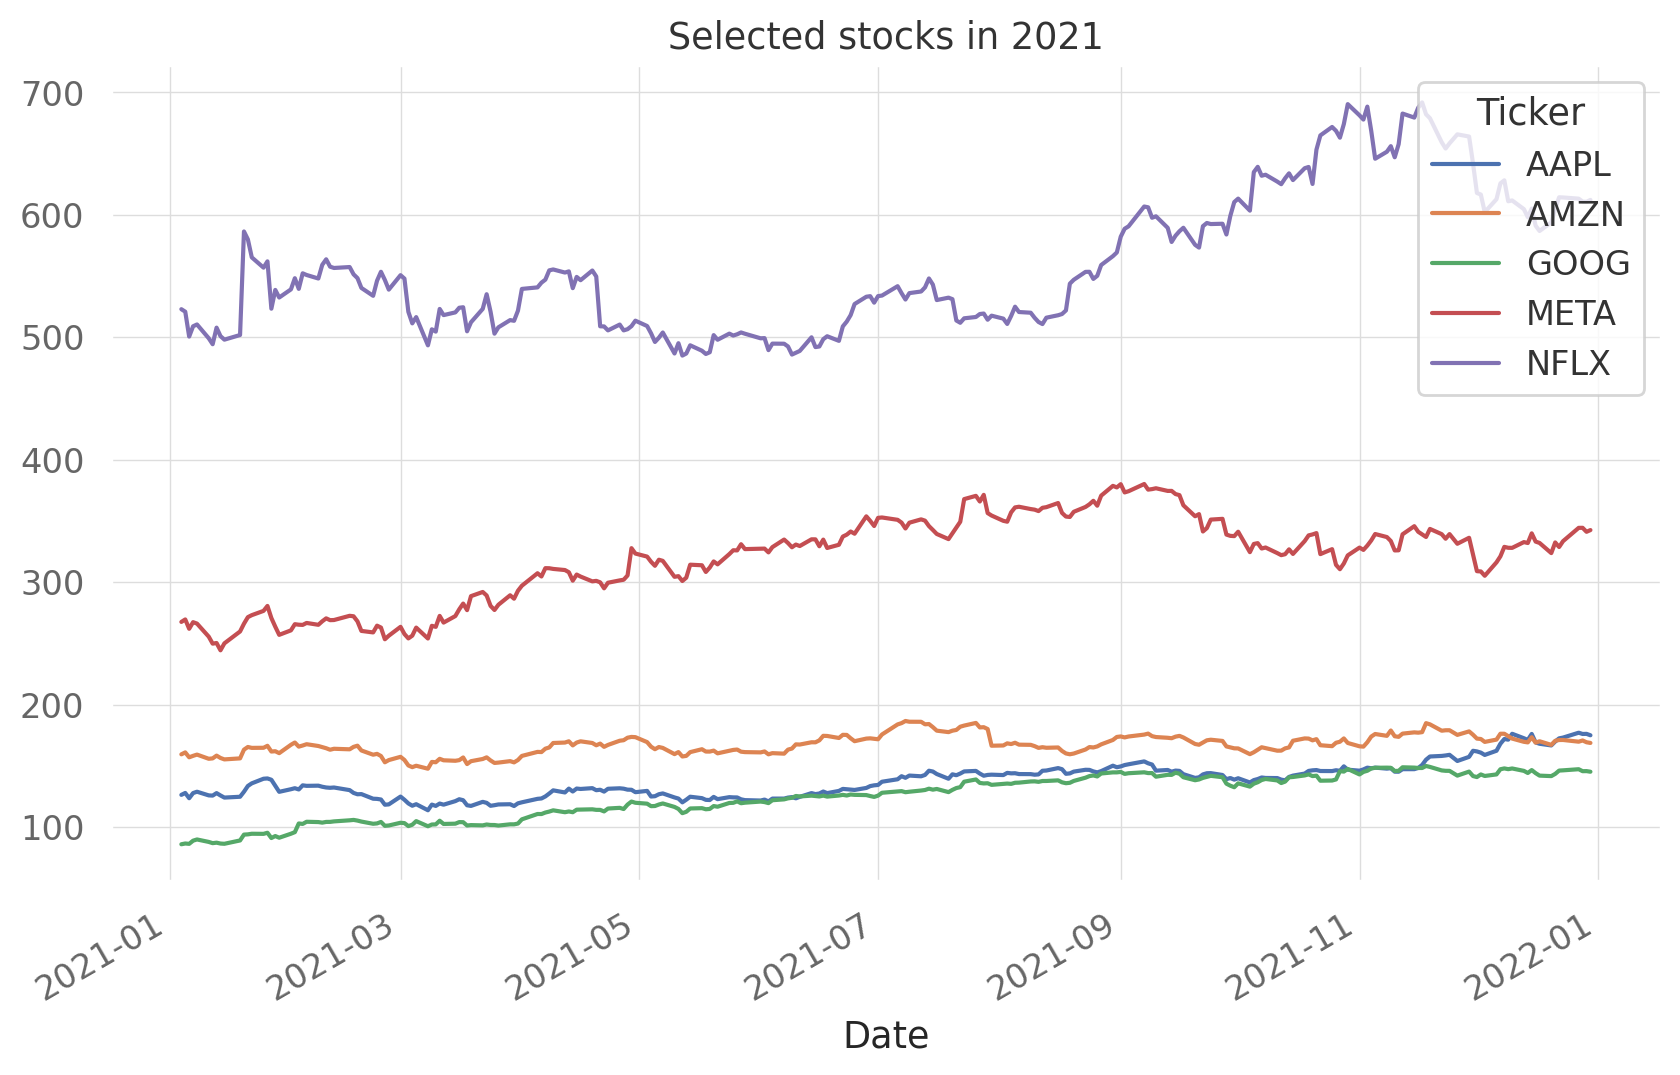

In [18]:
prices_df["Close"].plot(title="Selected stocks in 2021");

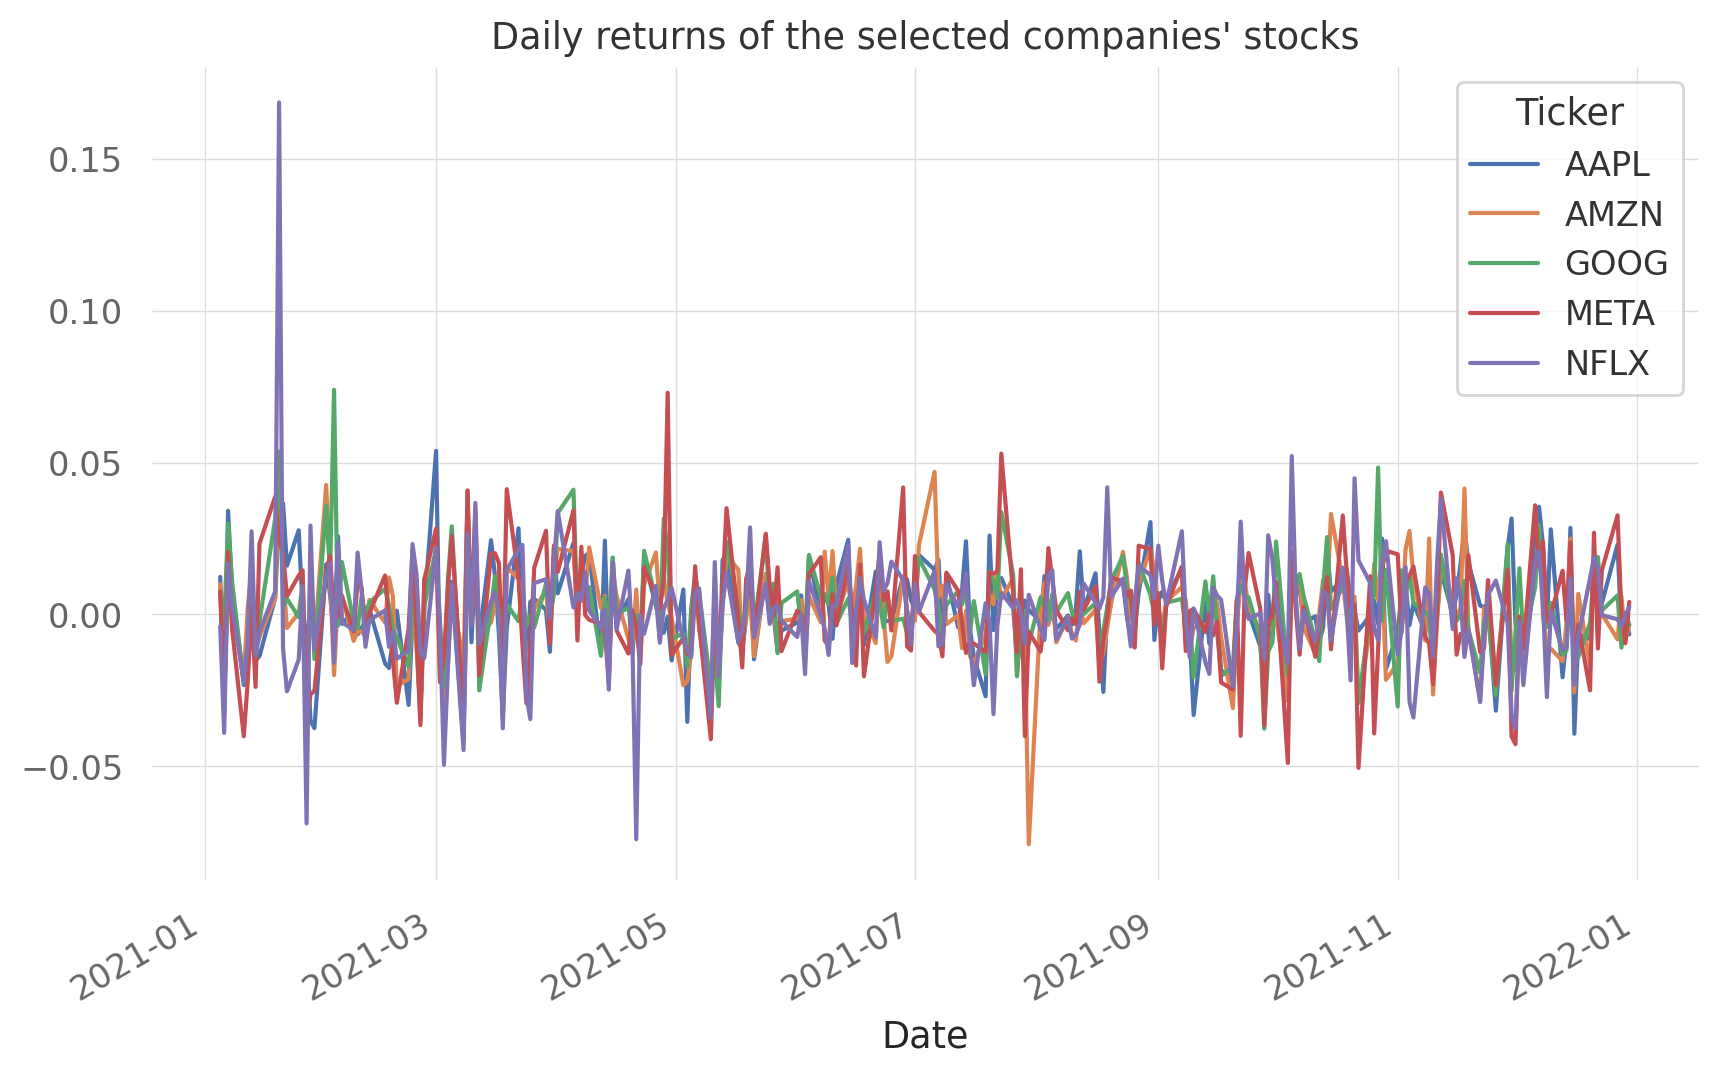

In [19]:
# 3) Calculate annualized average returns and the corresponding standard deviation:
returns_df = prices_df["Close"].pct_change().dropna()
avg_returns = returns_df.mean() * N_DAYS
cov_mat = returns_df.cov() * N_DAYS

returns_df.plot(title="Daily returns of the selected companies' stocks");

In [20]:
# 4) Simulate random portfolio weights:
np.random.seed(42)
weights = np.random.random(size=(N_PORTFOLIOS, n_assets))
weights /=  np.sum(weights, axis=1)[:, np.newaxis]

In [21]:
# 5) Calculate the portfolio metrics:
portf_rtns = np.dot(weights, avg_returns)

portf_vol = []
for i in range(0, len(weights)):
    vol = np.sqrt(
        np.dot(weights[i].T, np.dot(cov_mat, weights[i]))
    )
    portf_vol.append(vol)
portf_vol = np.array(portf_vol)

portf_sharpe_ratio = portf_rtns / portf_vol

In [22]:
# 6) Create a DataFrame containing all the data:
portf_results_df = pd.DataFrame(
    {"returns": portf_rtns,
     "volatility": portf_vol,
     "sharpe_ratio": portf_sharpe_ratio}
)
portf_results_df

,returns,volatility,sharpe_ratio
0,0.296033,0.206286,1.435056
1,0.363005,0.219444,1.654207
2,0.295368,0.207855,1.421030
3,0.329460,0.209253,1.574462
4,0.320218,0.211567,1.513554
...,...,...,...
99995,0.286108,0.205679,1.391042
99996,0.307062,0.206482,1.487116
99997,0.328534,0.209320,1.569532
99998,0.278324,0.213438,1.304003


In [23]:
# 7) Locate the points creating the Efficient Frontier:
N_POINTS = 50000

ef_rtn_list = []
ef_vol_list = []

possible_ef_rtns = np.linspace(
    portf_results_df["returns"].min(),
    portf_results_df["returns"].max(),
    N_POINTS
)
possible_ef_rtns = np.round(possible_ef_rtns, 2)
portf_rtns = np.round(portf_rtns, 2)

for rtn in possible_ef_rtns:
    if rtn in portf_rtns:
        ef_rtn_list.append(rtn)
        matched_ind = np.where(portf_rtns == rtn)
        ef_vol_list.append(np.min(portf_vol[matched_ind]))

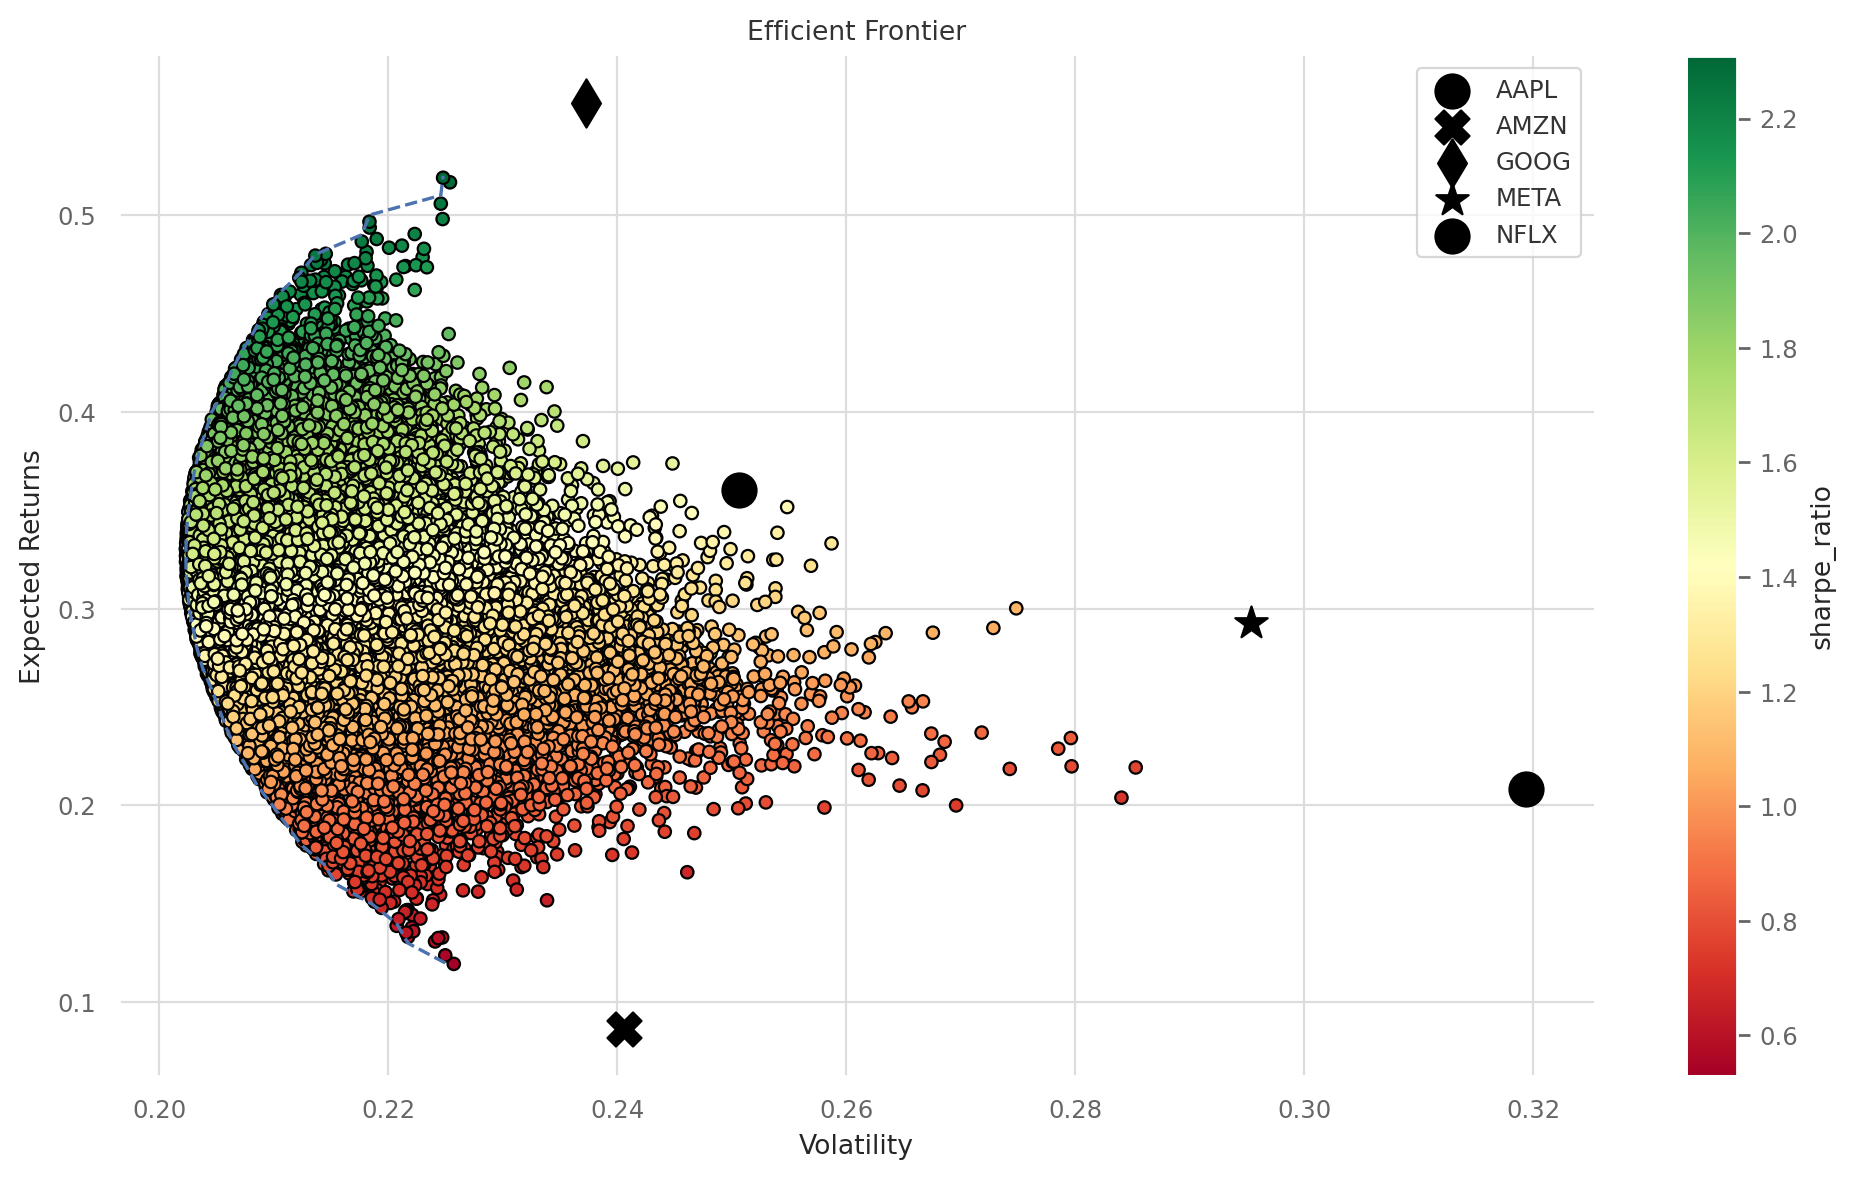

In [24]:
# 8) Plot the Efficient Frontier:
MARKERS = ["o", "X", "d", "*","o"]

with sns.plotting_context("paper"):
    fig, ax = plt.subplots()
    portf_results_df.plot(kind="scatter", x="volatility",
                          y="returns", c="sharpe_ratio",
                          cmap="RdYlGn", edgecolors="black",
                          ax=ax)
    ax.set(xlabel="Volatility",
           ylabel="Expected Returns",
           title="Efficient Frontier")
    ax.plot(ef_vol_list, ef_rtn_list, "b--")
    for asset_index in range(n_assets):
        ax.scatter(x=np.sqrt(cov_mat.iloc[asset_index, asset_index]),
                   y=avg_returns[asset_index],
                   marker=MARKERS[asset_index],
                   s=150, color="black",
                   label=ASSETS[asset_index])
    ax.legend()

    sns.despine()
    plt.tight_layout()
    # plt.savefig("images/figure_11_10", dpi=200)

In [25]:
max_sharpe_ind = np.argmax(portf_results_df["sharpe_ratio"])
max_sharpe_portf = portf_results_df.loc[max_sharpe_ind]

min_vol_ind = np.argmin(portf_results_df["volatility"])
min_vol_portf = portf_results_df.loc[min_vol_ind]

print_portfolio_summary(max_sharpe_portf,
                        weights[max_sharpe_ind],
                        ASSETS,
                        name="Maximum Sharpe Ratio")

Maximum Sharpe Ratio portfolio ----
Performance
returns: 51.89% volatility: 22.48% sharpe_ratio: 230.87% 
Weights
AAPL: 8.09% AMZN: 0.78% GOOG: 85.22% META: 2.42% NFLX: 3.50% 

In [26]:
print_portfolio_summary(min_vol_portf,
                        weights[min_vol_ind],
                        ASSETS,
                        name="Minimum Volatility")

Minimum Volatility portfolio ----
Performance
returns: 33.01% volatility: 20.23% sharpe_ratio: 163.18% 
Weights
AAPL: 24.23% AMZN: 26.63% GOOG: 32.13% META: 6.46% NFLX: 10.54% 

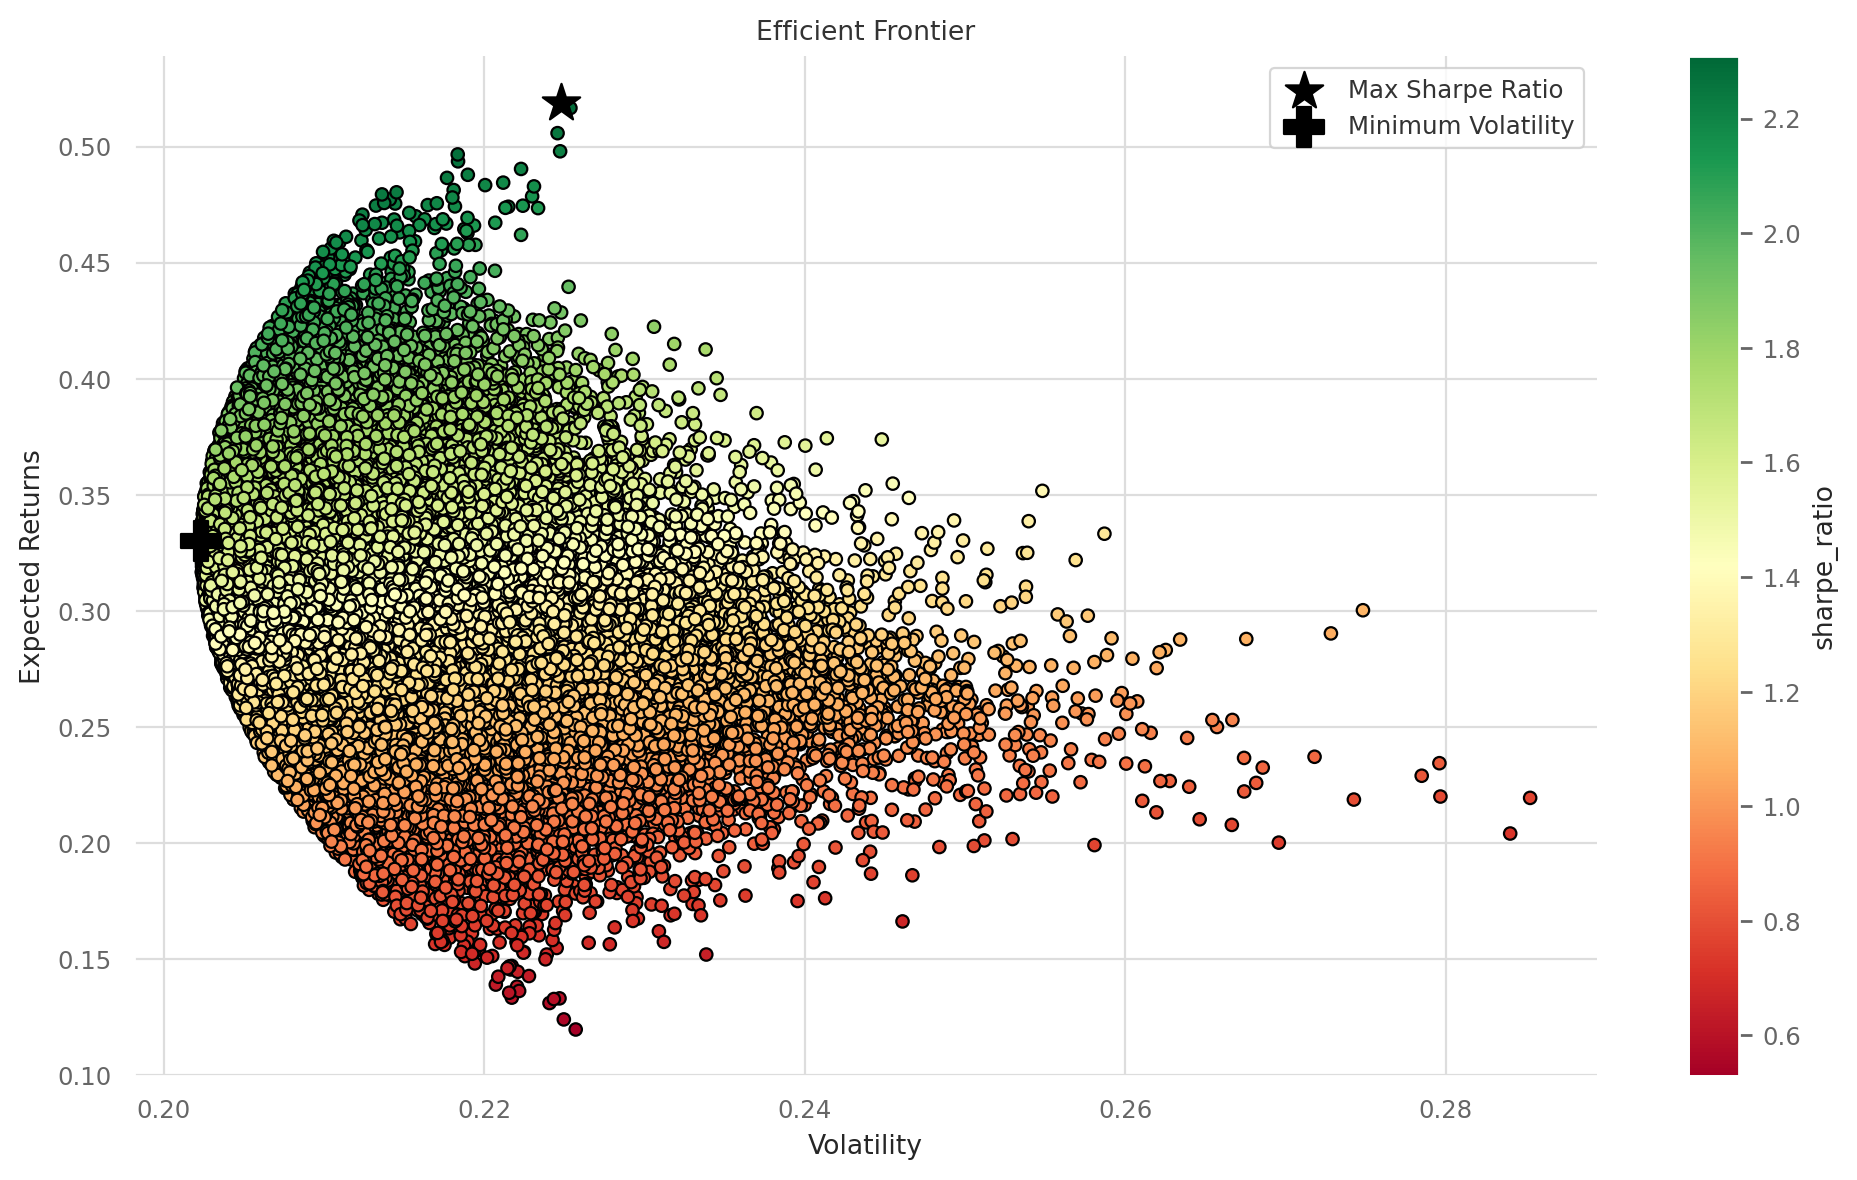

In [27]:
# Tracer la frontière efficiente
with sns.plotting_context("paper"):
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = portf_results_df.plot(
        kind="scatter",
        x="volatility",
        y="returns",
        c="sharpe_ratio",
        cmap="RdYlGn",
        edgecolors="black",
        ax=ax
    )

    # Ajouter les portefeuilles Max Sharpe et Min Vol
    ax.scatter(
        x=max_sharpe_portf["volatility"],
        y=max_sharpe_portf["returns"],
        c="black", marker="*", s=200, label="Max Sharpe Ratio"
    )
    ax.scatter(
        x=min_vol_portf["volatility"],
        y=min_vol_portf["returns"],
        c="black", marker="P", s=200, label="Minimum Volatility"
    )

    ax.set(
        xlabel="Volatility",
        ylabel="Expected Returns",
        title="Efficient Frontier"
    )
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

## Finding the efficient frontier using optimization with scipy

In [28]:
import scipy.optimize as sco

In [29]:
# 1) Define functions calculating portfolio returns and volatility:
def get_portf_rtn(w, avg_rtns):
    return np.sum(avg_rtns * w)

def get_portf_vol(w, avg_rtns, cov_mat):
    return np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))

# Define the function calculating the efficient frontier:
def get_efficient_frontier(avg_rtns, cov_mat, rtns_range):

    efficient_portfolios = []

    n_assets = len(avg_returns)
    args = (avg_returns, cov_mat)
    bounds = tuple((0,1) for asset in range(n_assets))
    initial_guess = n_assets * [1. / n_assets, ]

    for ret in rtns_range:
        constr = (
            {"type": "eq",
             "fun": lambda x: get_portf_rtn(x, avg_rtns) - ret},
            {"type": "eq",
             "fun": lambda x: np.sum(x) - 1}
        )
        ef_portf = sco.minimize(get_portf_vol,
                                initial_guess,
                                args=args, method="SLSQP",
                                constraints=constr,
                                bounds=bounds)
        efficient_portfolios.append(ef_portf)

    return efficient_portfolios

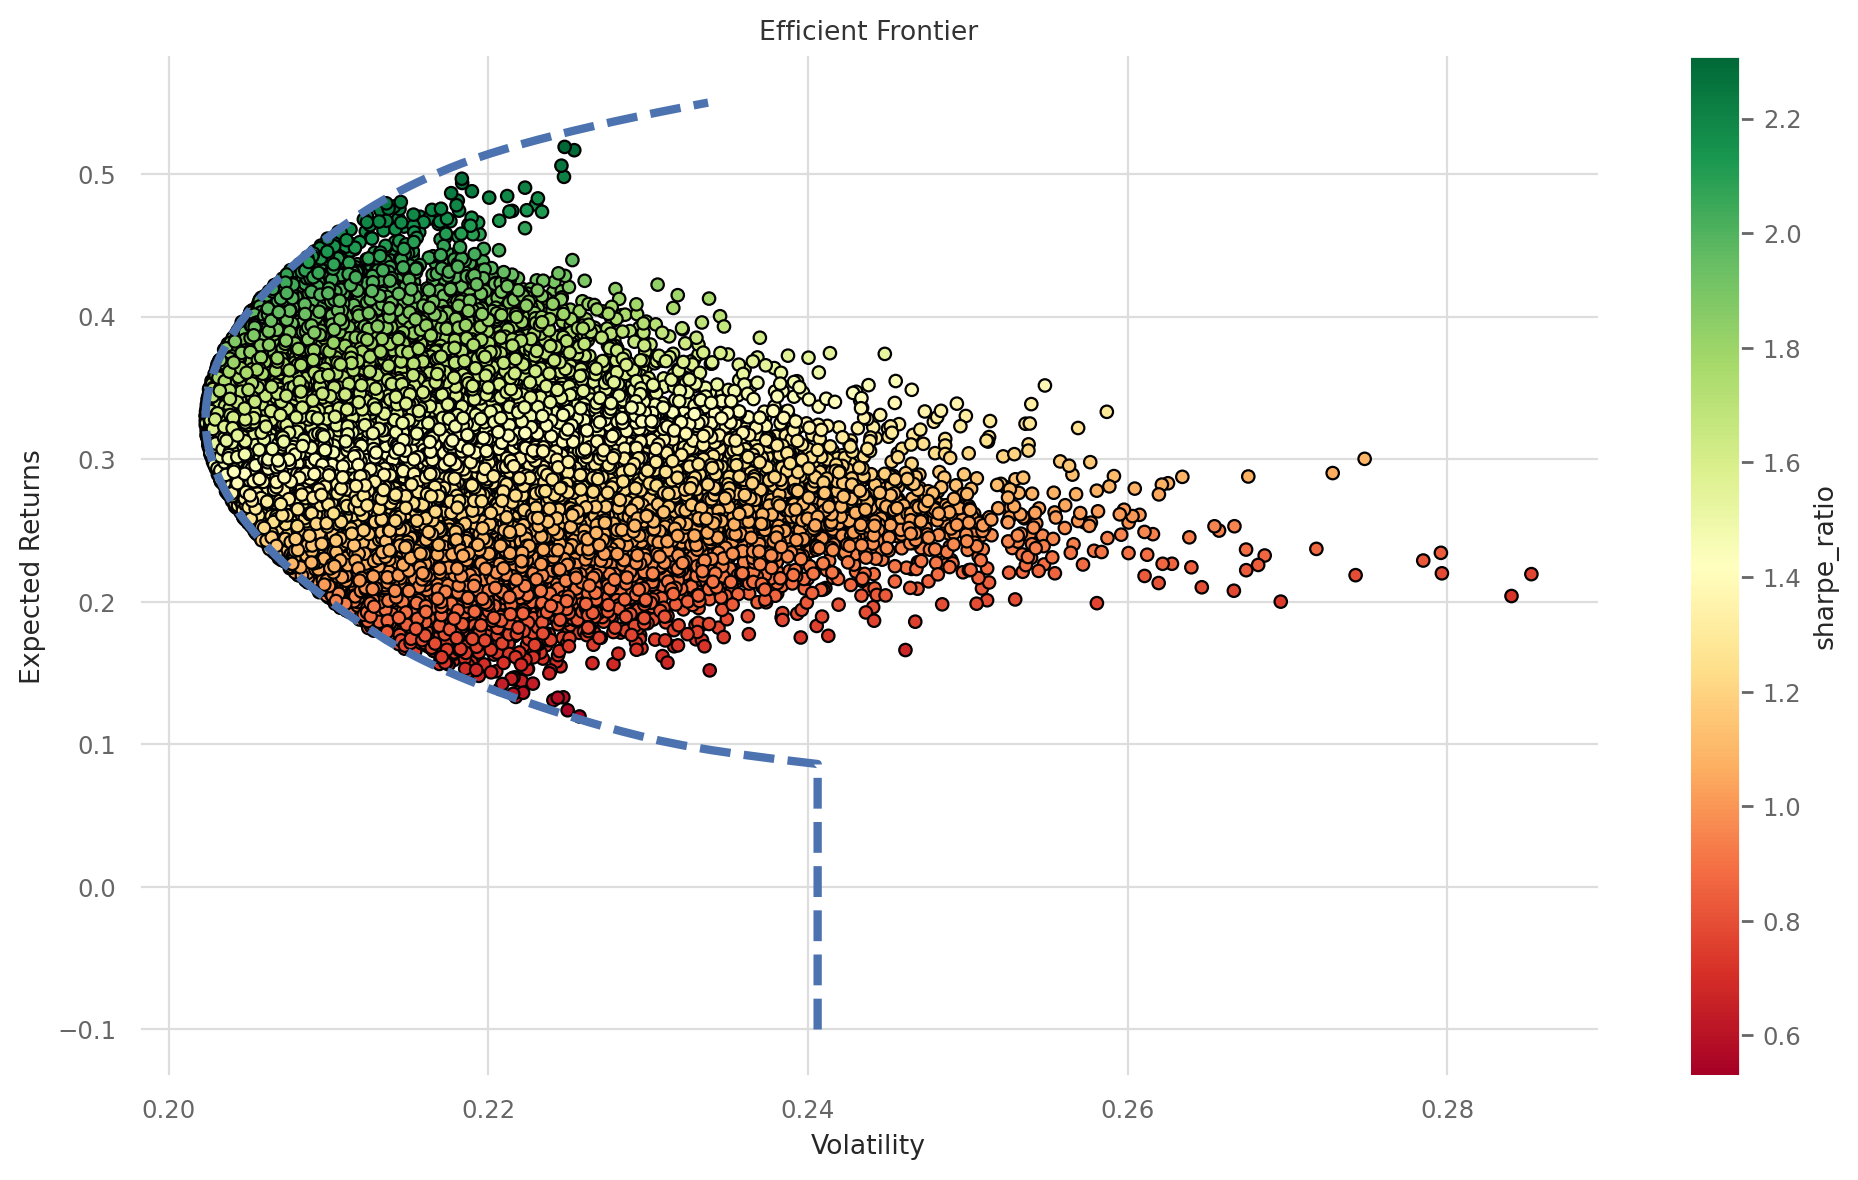

In [30]:
# 2) Define the considered range of expected portfolio returns:
rtns_range = np.linspace(-0.1, 0.55, 200)

# Calculate the Efficient Frontier:
efficient_portfolios = get_efficient_frontier(avg_returns,
                                              cov_mat,
                                              rtns_range)

# Extract the volatilities of the efficient portfolios:
vols_range = [x["fun"] for x in efficient_portfolios]

# Plot the calculated Efficient Frontier, together with the simulated portfolios:
with sns.plotting_context("paper"):
    fig, ax = plt.subplots()
    portf_results_df.plot(kind="scatter", x="volatility",
                          y="returns", c="sharpe_ratio",
                          cmap="RdYlGn", edgecolors="black",
                          ax=ax)
    ax.plot(vols_range, rtns_range, "b--", linewidth=3)
    ax.set(xlabel="Volatility",
           ylabel="Expected Returns",
           title="Efficient Frontier")

    sns.despine()
    plt.tight_layout()


In [31]:
# Identify the minimum volatility portfolio:
min_vol_ind = np.argmin(vols_range)
min_vol_portf_rtn = rtns_range[min_vol_ind]
min_vol_portf_vol = efficient_portfolios[min_vol_ind]["fun"]

min_vol_portf = {
    "Return": min_vol_portf_rtn,
    "Volatility": min_vol_portf_vol,
    "Sharpe Ratio": (min_vol_portf_rtn / min_vol_portf_vol)
}

min_vol_portf


{'Return': np.float64(0.32788944723618085),
 'Volatility': np.float64(0.20230460684276855),
 'Sharpe Ratio': np.float64(1.6207710360793566)}

In [32]:
# Print the performance summary:
print_portfolio_summary(min_vol_portf,
                        efficient_portfolios[min_vol_ind]["x"],
                        ASSETS,
                        name="Minimum Volatility")

Minimum Volatility portfolio ----
Performance
Return: 32.79% Volatility: 20.23% Sharpe Ratio: 162.08% 
Weights
AAPL: 24.46% AMZN: 27.47% GOOG: 31.82% META: 5.91% NFLX: 10.35% 

In [33]:
# Define the new objective function (negative Sharpe ratio):
def neg_sharpe_ratio(w, avg_rtns, cov_mat, rf_rate):
    portf_returns = np.sum(avg_rtns * w)
    portf_volatility = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
    portf_sharpe_ratio = (
        (portf_returns - rf_rate) / portf_volatility
    )
    return -portf_sharpe_ratio

In [34]:
# Find the optimized portfolio:
n_assets = len(avg_returns)
RF_RATE = 0

args = (avg_returns, cov_mat, RF_RATE)
constraints = ({"type": "eq",
                "fun": lambda x: np.sum(x) - 1})
bounds = tuple((0,1) for asset in range(n_assets))
initial_guess = n_assets * [1. / n_assets]

max_sharpe_portf = sco.minimize(neg_sharpe_ratio,
                                x0=initial_guess,
                                args=args,
                                method="SLSQP",
                                bounds=bounds,
                                constraints=constraints)

In [35]:
# Extract information about the maximum Sharpe Ratio portfolio:
max_sharpe_portf_w = max_sharpe_portf["x"]
max_sharpe_portf = {
    "Return": get_portf_rtn(max_sharpe_portf_w, avg_returns),
    "Volatility": get_portf_vol(max_sharpe_portf_w,
                                avg_returns,
                                cov_mat),
    "Sharpe Ratio": -max_sharpe_portf["fun"]
}
max_sharpe_portf


{'Return': np.float64(0.539635142939162),
 'Volatility': np.float64(0.22907205557585406),
 'Sharpe Ratio': np.float64(2.355744097998323)}

In [36]:
print_portfolio_summary(max_sharpe_portf,
                        max_sharpe_portf_w,
                        ASSETS,
                        name="Maximum Sharpe Ratio")


Maximum Sharpe Ratio portfolio ----
Performance
Return: 53.96% Volatility: 22.91% Sharpe Ratio: 235.57% 
Weights
AAPL: 8.88% AMZN: 0.00% GOOG: 91.12% META: 0.00% NFLX: 0.00% 

## Finding the efficient frontier using convex optimization with cvxpy

In [37]:
import cvxpy as cp

In [38]:
# Convert the annualized average returns and the covariance matrix to numpy arrays:

avg_returns = avg_returns.values
cov_mat = cov_mat.values

In [39]:
# Set up the optimization problem:
weights = cp.Variable(n_assets)
gamma_par = cp.Parameter(nonneg=True)
portf_rtn_cvx = avg_returns @ weights
portf_vol_cvx = cp.quad_form(weights, cov_mat)
objective_function = cp.Maximize(
    portf_rtn_cvx - gamma_par * portf_vol_cvx
)
problem = cp.Problem(
    objective_function,
    [cp.sum(weights) == 1, weights >= 0]
)

In [40]:
# Calculate the Efficient Frontier:
N_POINTS = 25
portf_rtn_cvx_ef = []
portf_vol_cvx_ef = []
weights_ef = []
gamma_range = np.logspace(-3, 3, num=N_POINTS)

for gamma in gamma_range:
    gamma_par.value = gamma
    problem.solve()
    portf_vol_cvx_ef.append(cp.sqrt(portf_vol_cvx).value)
    portf_rtn_cvx_ef.append(portf_rtn_cvx.value)
    weights_ef.append(weights.value)

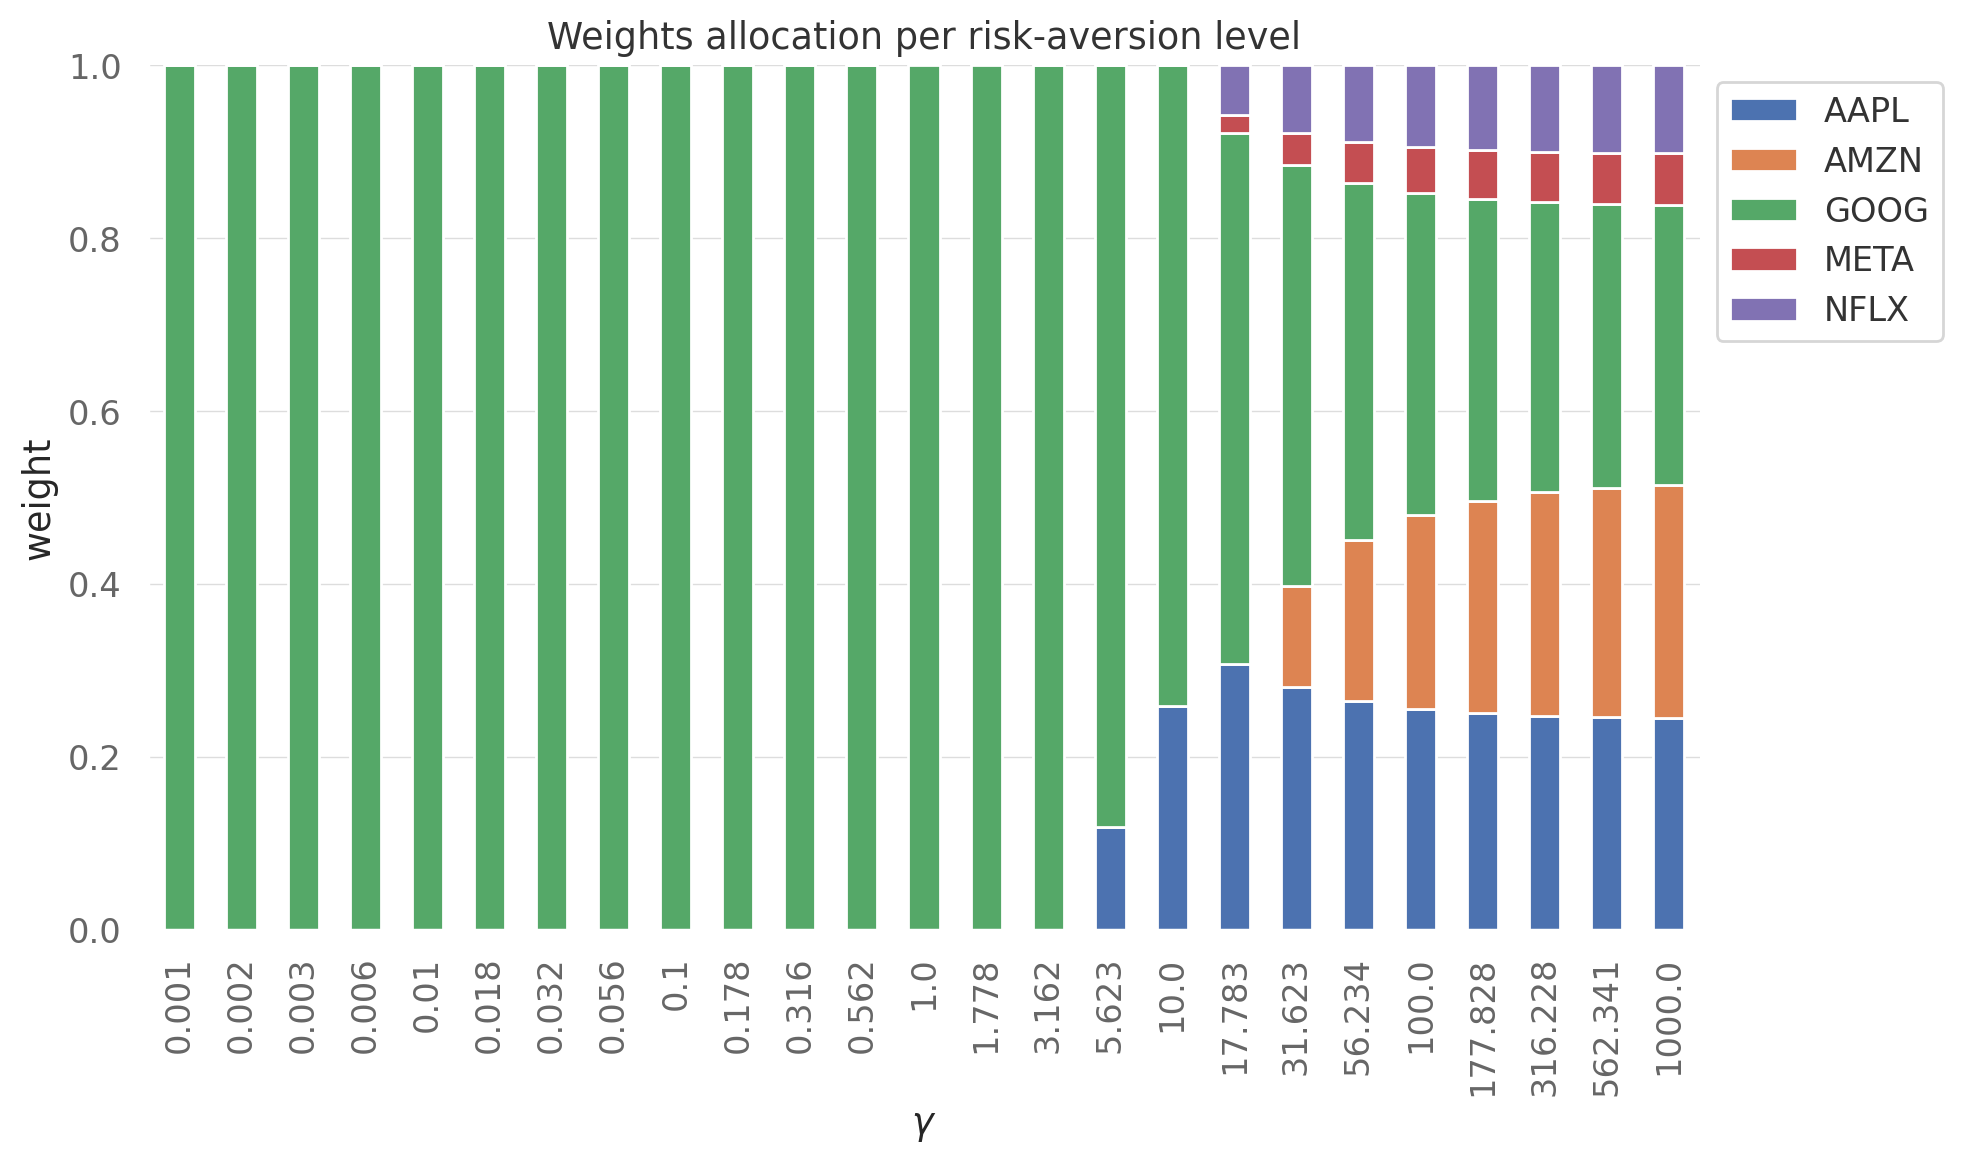

In [41]:
# Plot the allocation for different values of the risk-aversion parameter:
weights_df = pd.DataFrame(weights_ef,
                          columns=ASSETS,
                          index=np.round(gamma_range, 3))
ax = weights_df.plot(kind="bar", stacked=True)
ax.set(title="Weights allocation per risk-aversion level",
       xlabel=r"$\gamma$",
       ylabel="weight")
ax.legend(bbox_to_anchor=(1,1))

sns.despine()
plt.tight_layout()
# plt.savefig("images/figure_11_13", dpi=200)

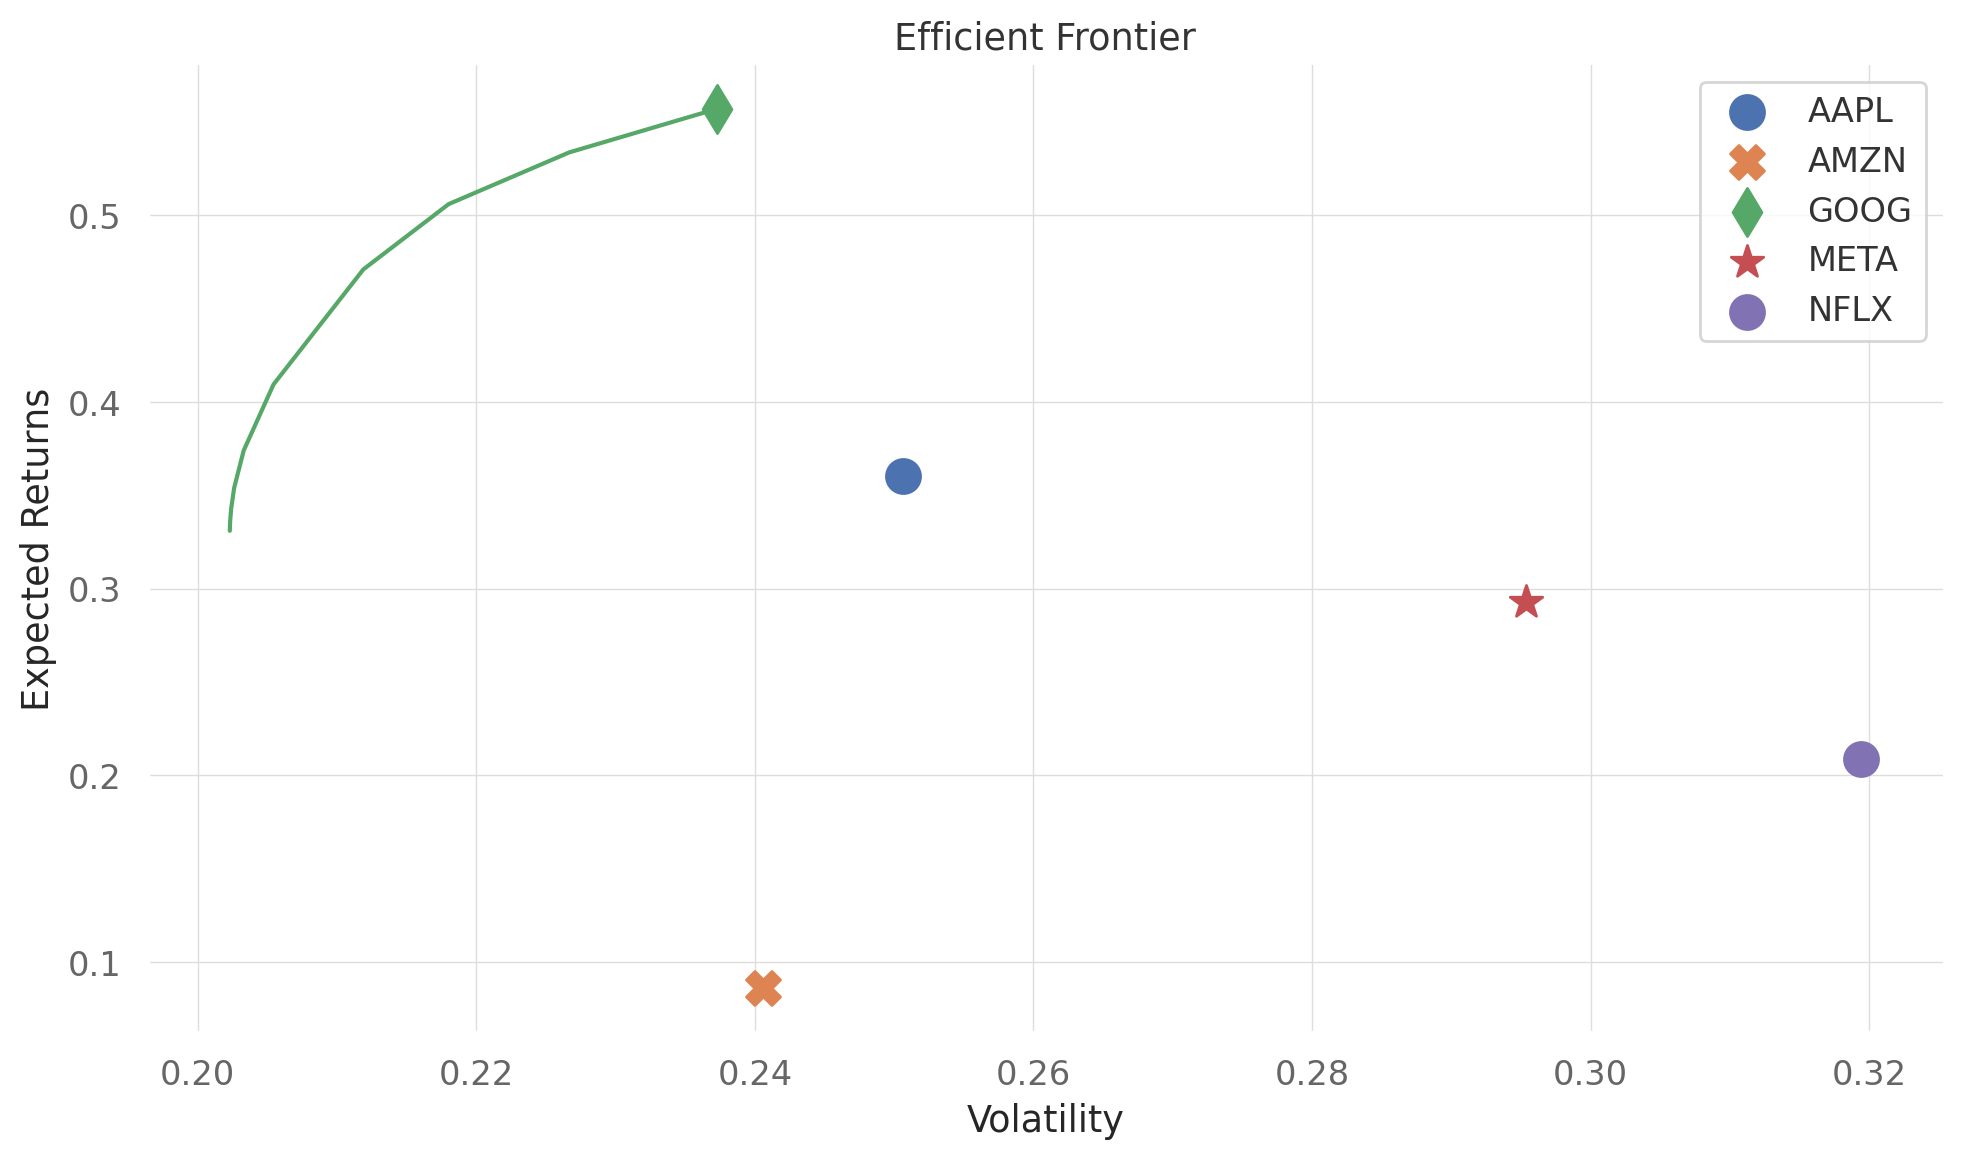

In [42]:
# Plot the Efficient Frontier, together with the individual assets:
#MARKERS = ["o", "X", "d", "*"]

fig, ax = plt.subplots()
ax.plot(portf_vol_cvx_ef, portf_rtn_cvx_ef, "g-")
for asset_index in range(n_assets):
     plt.scatter(x=np.sqrt(cov_mat[asset_index, asset_index]),
                 y=avg_returns[asset_index],
                 marker=MARKERS[asset_index],
                 label=ASSETS[asset_index],
                 s=150)
ax.set(title="Efficient Frontier",
       xlabel="Volatility",
       ylabel="Expected Returns")
ax.legend()

sns.despine()
plt.tight_layout()
# plt.savefig("images/figure_11_14", dpi=200)

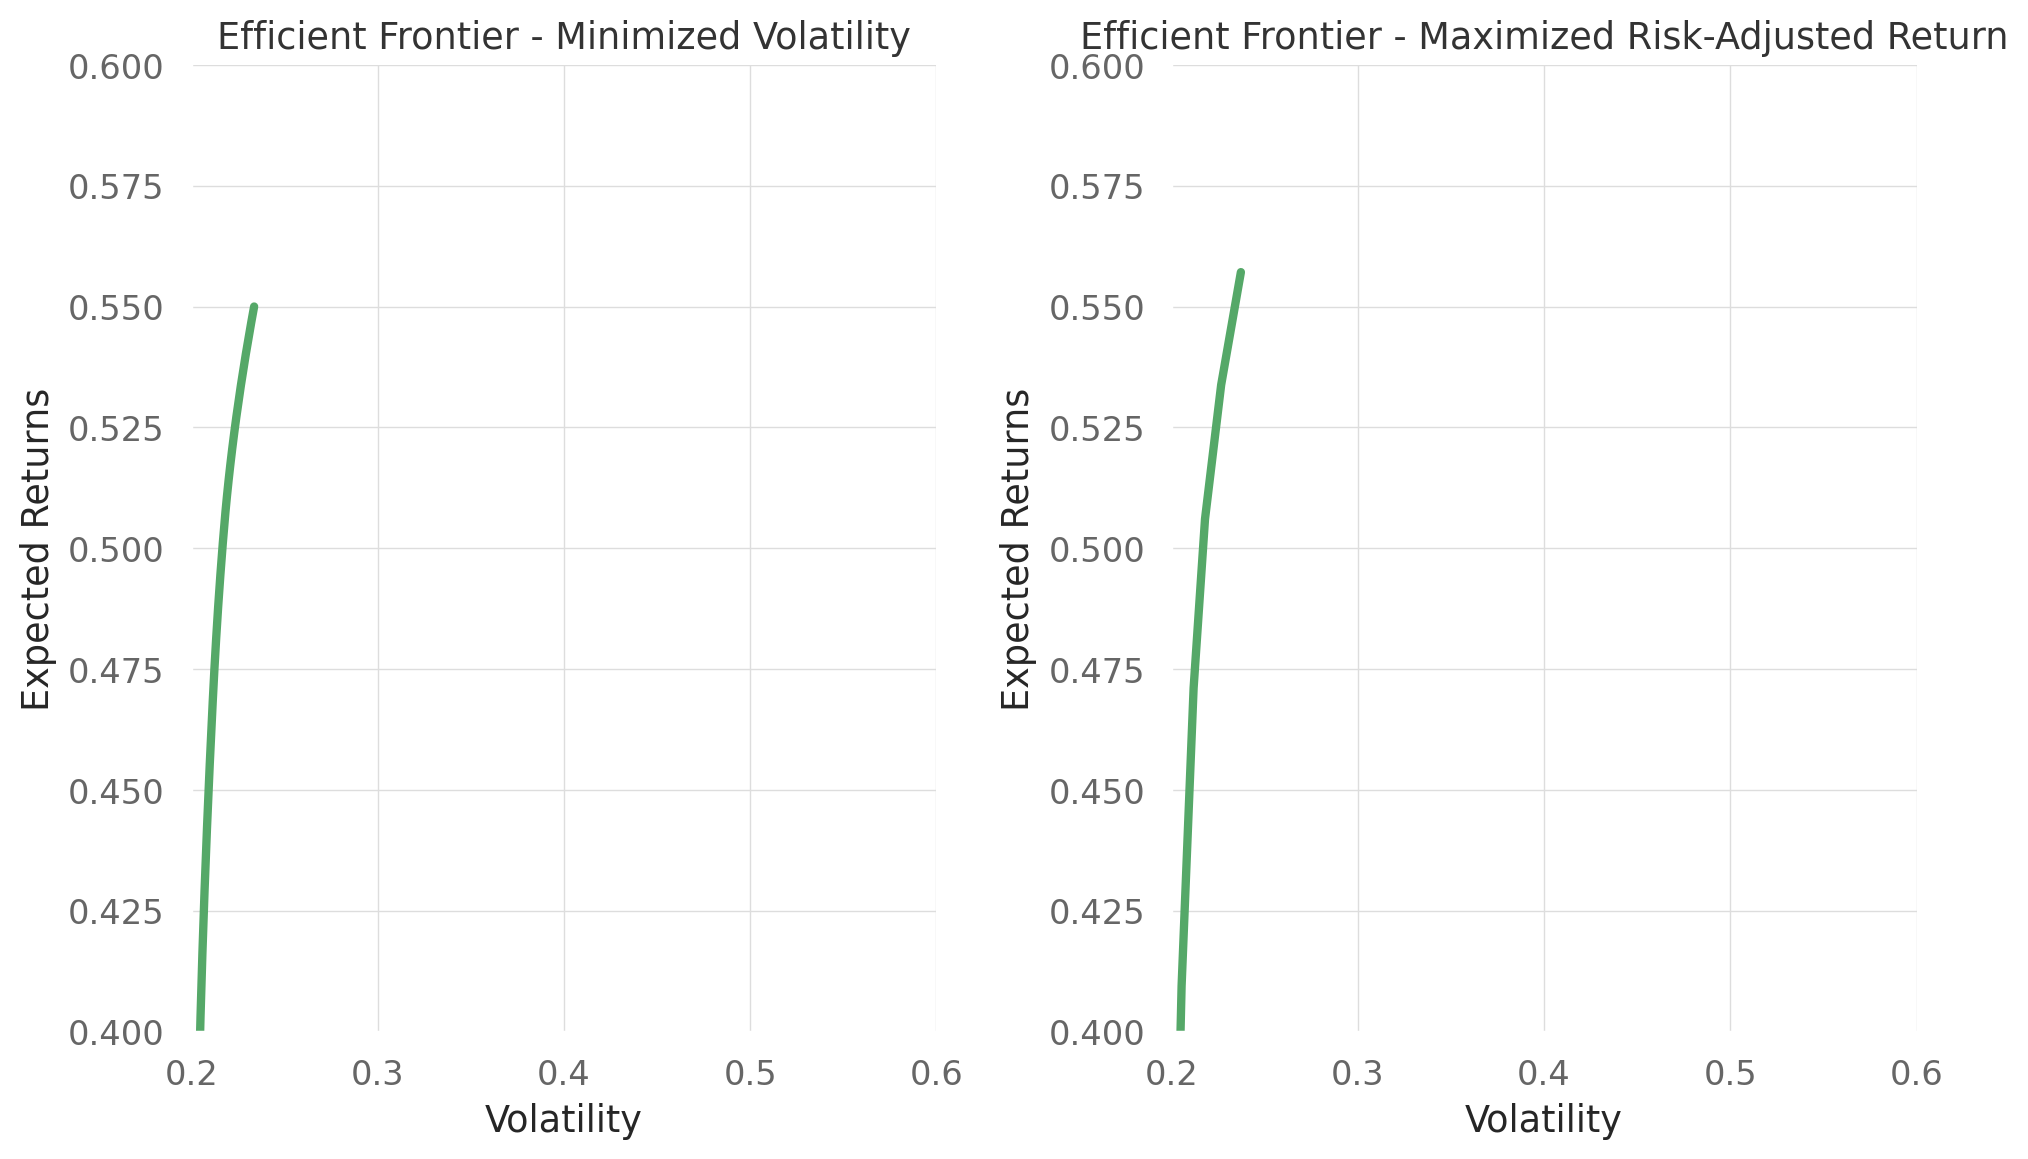

In [43]:
x_lim = [0.2, 0.6]
y_lim = [0.4, 0.6]

fig, ax = plt.subplots(1, 2)
ax[0].plot(vols_range, rtns_range, "g-", linewidth=3)
ax[0].set(title="Efficient Frontier - Minimized Volatility",
          xlabel="Volatility",
          ylabel="Expected Returns",
          xlim=x_lim,
          ylim=y_lim)

ax[1].plot(portf_vol_cvx_ef, portf_rtn_cvx_ef, "g-", linewidth=3)
ax[1].set(title="Efficient Frontier - Maximized Risk-Adjusted Return",
          xlabel="Volatility",
          ylabel="Expected Returns",
          xlim=x_lim,
          ylim=y_lim)

sns.despine()
plt.tight_layout()
# plt.savefig("images/figure_11_15", dpi=200)

In [44]:
max_leverage = cp.Parameter()
prob_with_leverage = cp.Problem(objective_function,
                                [cp.sum(weights) == 1,
                                cp.norm(weights, 1) <= max_leverage])

In [45]:
LEVERAGE_RANGE = [1, 2, 5]
len_leverage = len(LEVERAGE_RANGE)
N_POINTS = 25

portf_vol_l = np.zeros((N_POINTS, len_leverage))
portf_rtn_l = np.zeros(( N_POINTS, len_leverage))
weights_ef = np.zeros((len_leverage, N_POINTS, n_assets))

for lev_ind, leverage in enumerate(LEVERAGE_RANGE):
    for gamma_ind in range(N_POINTS):
        max_leverage.value = leverage
        gamma_par.value = gamma_range[gamma_ind]
        prob_with_leverage.solve()
        portf_vol_l[gamma_ind, lev_ind] = cp.sqrt(portf_vol_cvx).value
        portf_rtn_l[gamma_ind, lev_ind] = portf_rtn_cvx.value
        weights_ef[lev_ind, gamma_ind, :] = weights.value


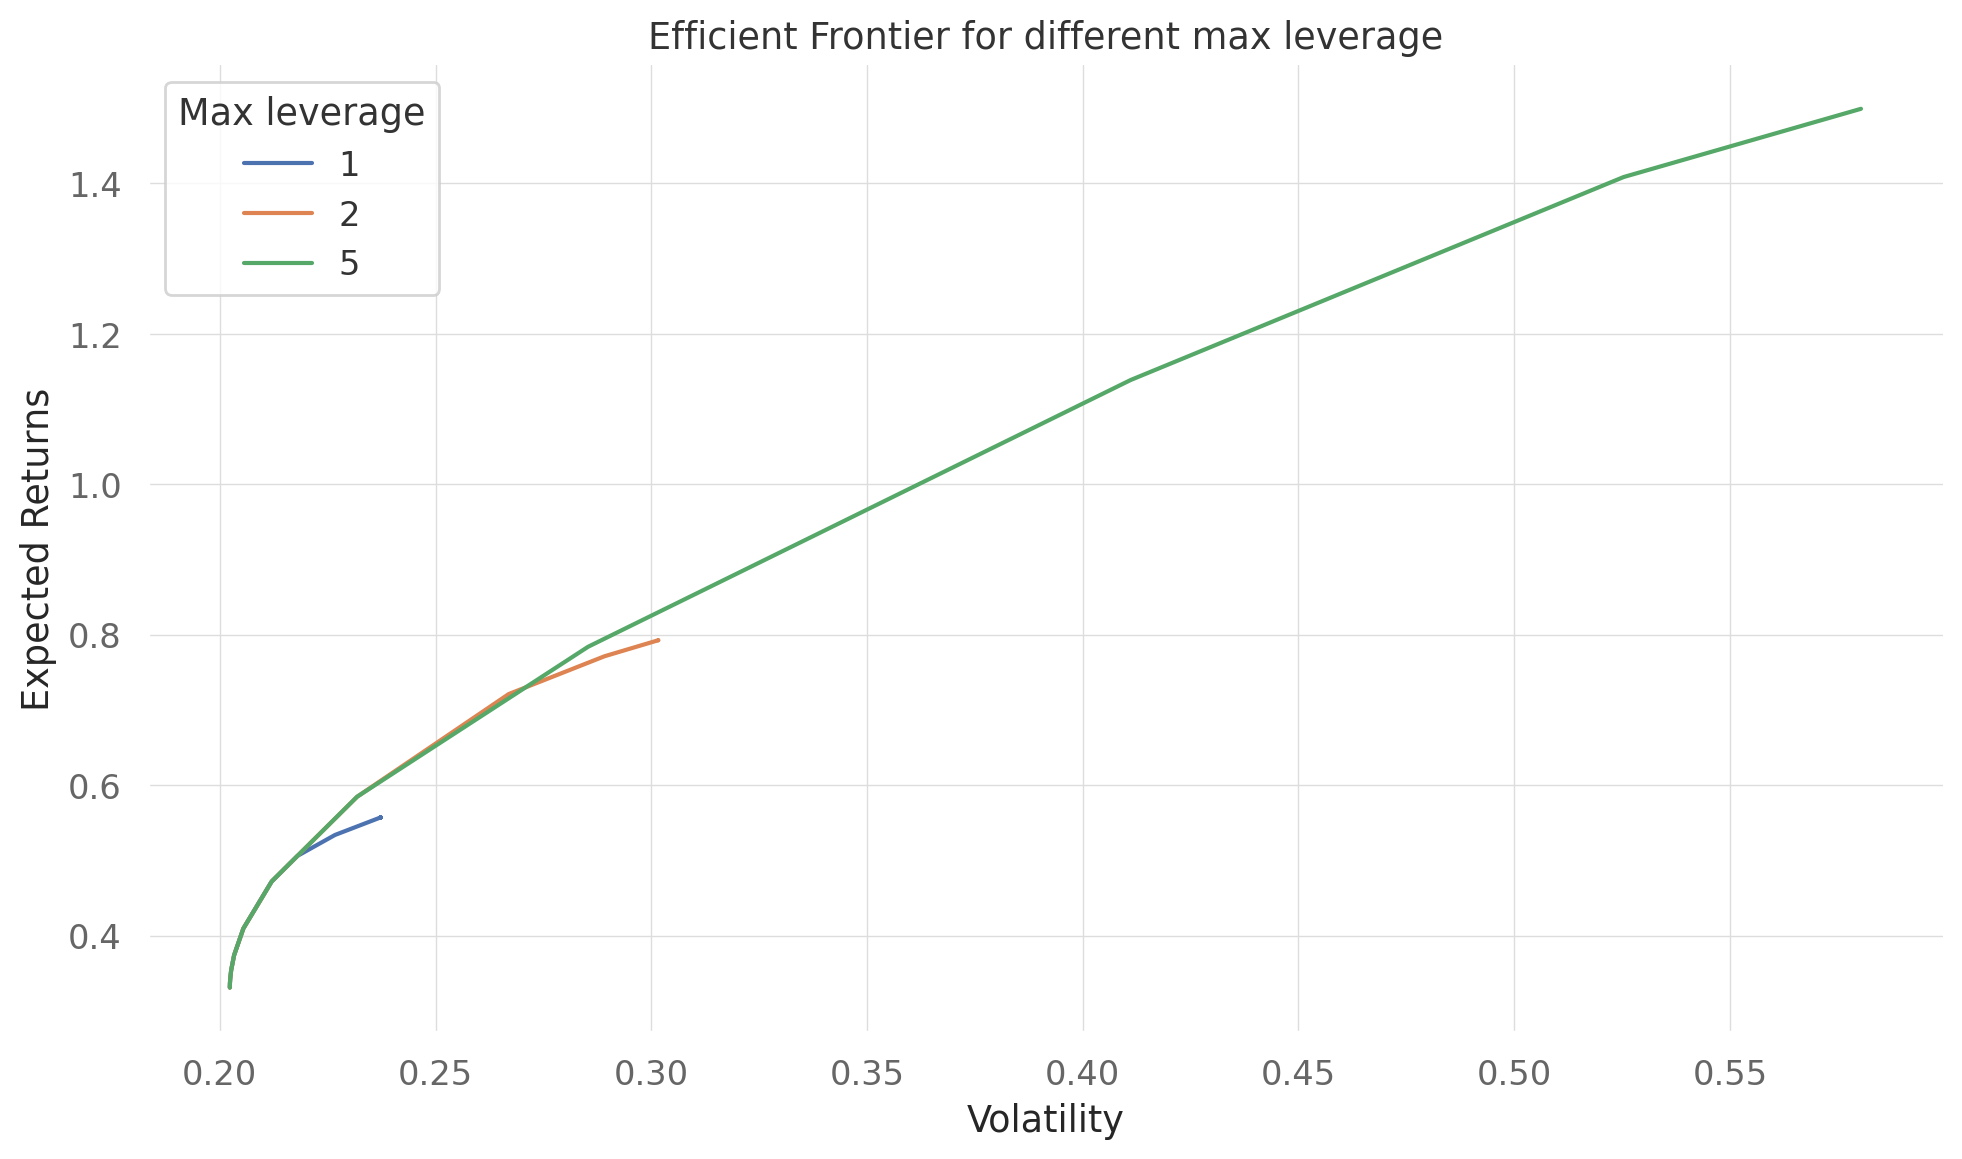

In [46]:
fig, ax = plt.subplots()

for leverage_index, leverage in enumerate(LEVERAGE_RANGE):
    plt.plot(portf_vol_l[:, leverage_index],
             portf_rtn_l[:, leverage_index],
             label=f"{leverage}")

ax.set(title="Efficient Frontier for different max leverage",
       xlabel="Volatility",
       ylabel="Expected Returns")
ax.legend(title="Max leverage")

sns.despine()
plt.tight_layout()
# plt.savefig("images/figure_11_16", dpi=200)

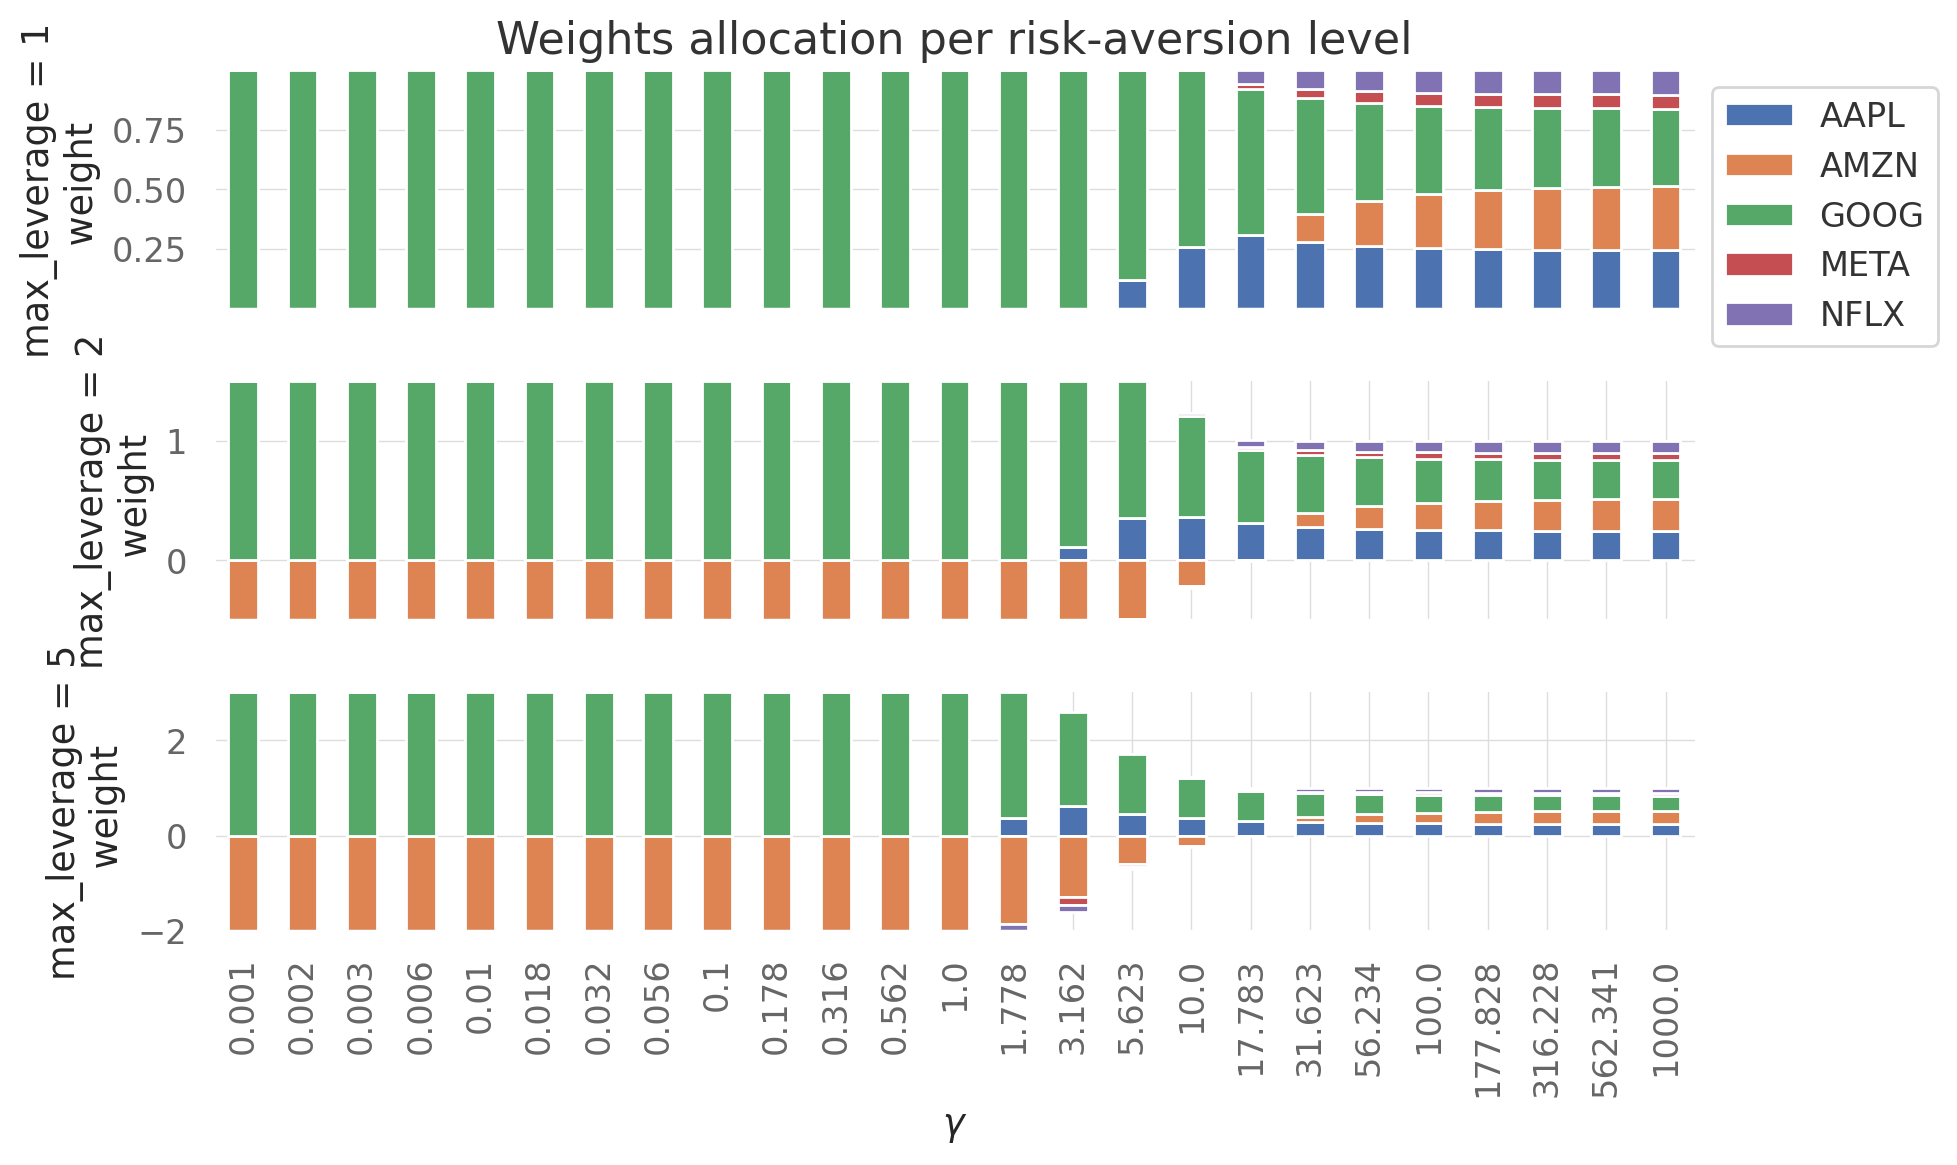

In [47]:
fig, ax = plt.subplots(len_leverage, 1, sharex=True)

for ax_index in range(len_leverage):
    weights_df = pd.DataFrame(weights_ef[ax_index],
                              columns=ASSETS,
                              index=np.round(gamma_range, 3))
    weights_df.plot(kind="bar",
                    stacked=True,
                    ax=ax[ax_index],
                    legend=None)
    ax[ax_index].set(
        ylabel=(f"max_leverage = {LEVERAGE_RANGE[ax_index]}"
                "\n weight")
    )


ax[len_leverage - 1].set(xlabel=r"$\gamma$")
ax[0].legend(bbox_to_anchor=(1,1))
ax[0].set_title("Weights allocation per risk-aversion level",
                fontsize=16)

sns.despine()
plt.tight_layout()
# plt.savefig("images/figure_11_17", dpi=200)

## Finding the optimal portfolio with Hierarchical Risk Parity

In [48]:
!pip install git+https://github.com/robertmartin8/PyPortfolioOpt.git

  Cloning https://github.com/robertmartin8/PyPortfolioOpt.git to /tmp/pip-req-build-jo2082_j
  Running command git clone --filter=blob:none --quiet https://github.com/robertmartin8/PyPortfolioOpt.git /tmp/pip-req-build-jo2082_j
  Resolved https://github.com/robertmartin8/PyPortfolioOpt.git to commit 65cabcee11d91777d63628744c36869ec64a1c85
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pyportfolioopt: filename=pyportfolioopt-1.5.6-py3-none-any.whl size=62666 sha256=0b40098fba092e708adfbbac124f13db2e47fa83c166904afea13adca21d9413
  Stored in directory: /tmp/pip-ephem-wheel-cache-2h9789ed/wheels/fb/ce/b5/02542dd1fd3a76e4df96e0e99a11cd0f2009bee8700affdbd1
Successfully built pyportfolioopt


In [49]:
from pypfopt.expected_returns import returns_from_prices
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.discrete_allocation import (
    DiscreteAllocation, get_latest_prices
)
from pypfopt import plotting

In [50]:
ASSETS = ["META", "AMZN", "AAPL", "NFLX", "GOOG"]

prices_df = yf.download(ASSETS,
                        start="2021-01-01",
                        end="2021-12-31")
prices_df = prices_df["Close"]
prices_df

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOG,META,NFLX
Date,,,,,
2021-01-04,126.239716,159.331497,85.901390,267.472687,522.859985
2021-01-05,127.800499,160.925507,86.531647,269.491547,520.799988
2021-01-06,123.498535,156.919006,86.251808,261.873322,500.489990
2021-01-07,127.712677,158.108002,88.834457,267.273712,508.890015
2021-01-08,128.815033,159.134995,89.826553,266.110138,510.399994
...,...,...,...,...,...
2021-12-23,173.021576,171.068497,146.273026,333.410858,614.090027
2021-12-27,176.996719,169.669495,147.189072,344.291199,613.119995
2021-12-28,175.975891,170.660995,145.582642,344.330994,610.710022


In [51]:
# Calculate the returns from prices:
rtn_df = returns_from_prices(prices_df)

In [52]:
# Find the optimal allocation using Hierarchical Risk Parity:
hrp = HRPOpt(returns=rtn_df)
hrp.optimize()

OrderedDict([('AAPL', np.float64(0.15837404275283545)),
             ('AMZN', np.float64(0.17181462816211185)),
             ('GOOG', np.float64(0.2808763684979917)),
             ('META', np.float64(0.20965239292694213)),
             ('NFLX', np.float64(0.17928256766011888))])

In [53]:
# Display the (cleaned) weights:
weights = hrp.clean_weights()
print(weights)

OrderedDict([('AAPL', 0.15837), ('AMZN', 0.17181), ('GOOG', 0.28088), ('META', 0.20965), ('NFLX', 0.17928)])


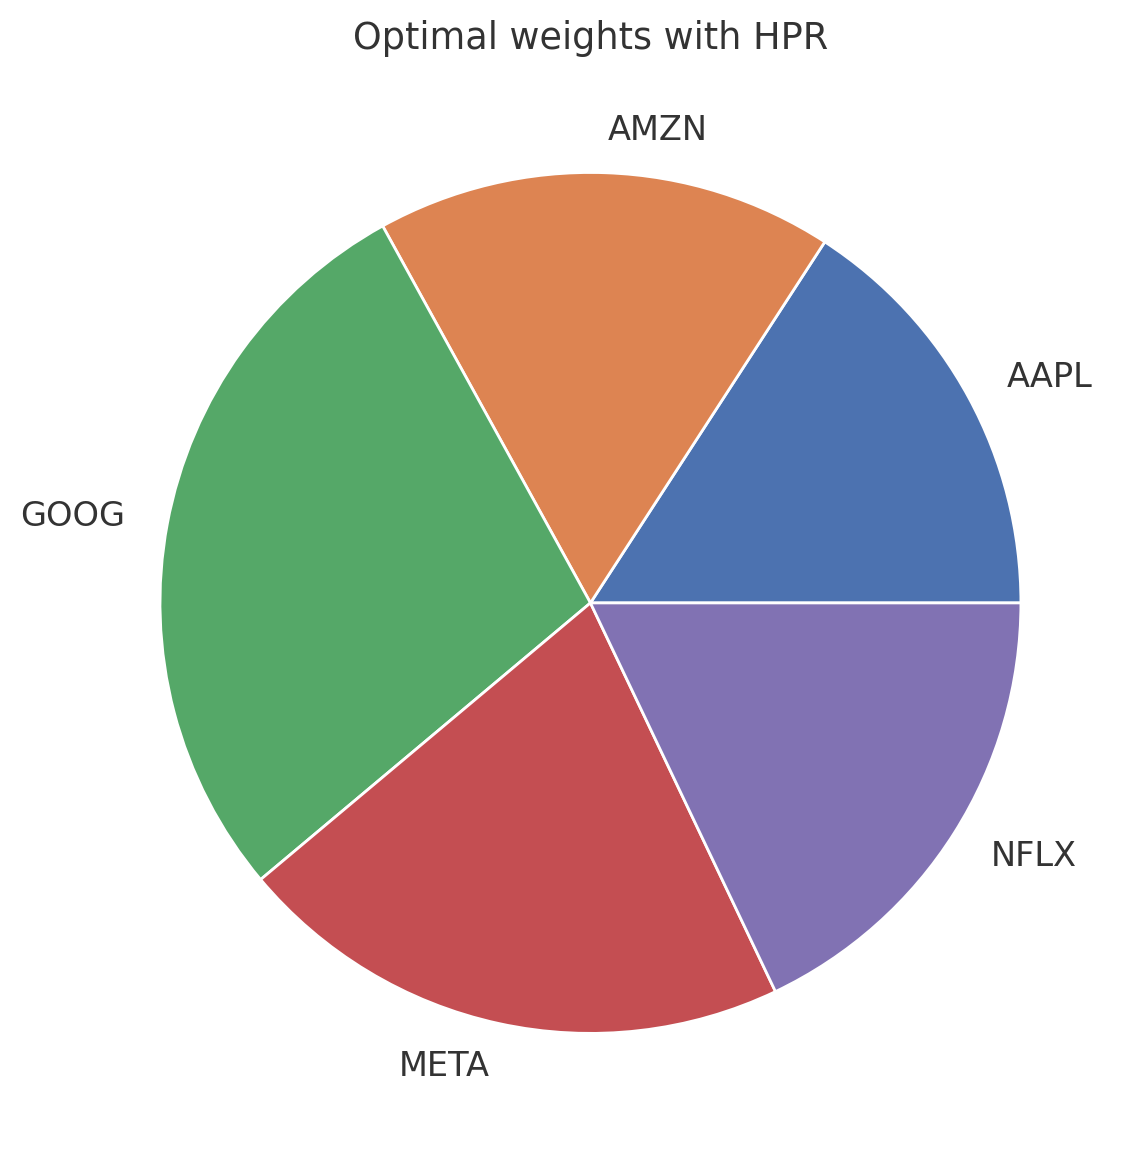

In [54]:
# We can create a simple pie chart to visualize the optimized portfolio weights:

pd.Series(weights).plot(kind="pie",
                        title="Optimal weights with HPR");

sns.despine()
plt.tight_layout()

In [55]:
# Calculate the portfolio performance:
hrp.portfolio_performance(verbose=True, risk_free_rate=0);

Expected annual return: 32.7%
Annual volatility: 20.7%
Sharpe Ratio: 1.58


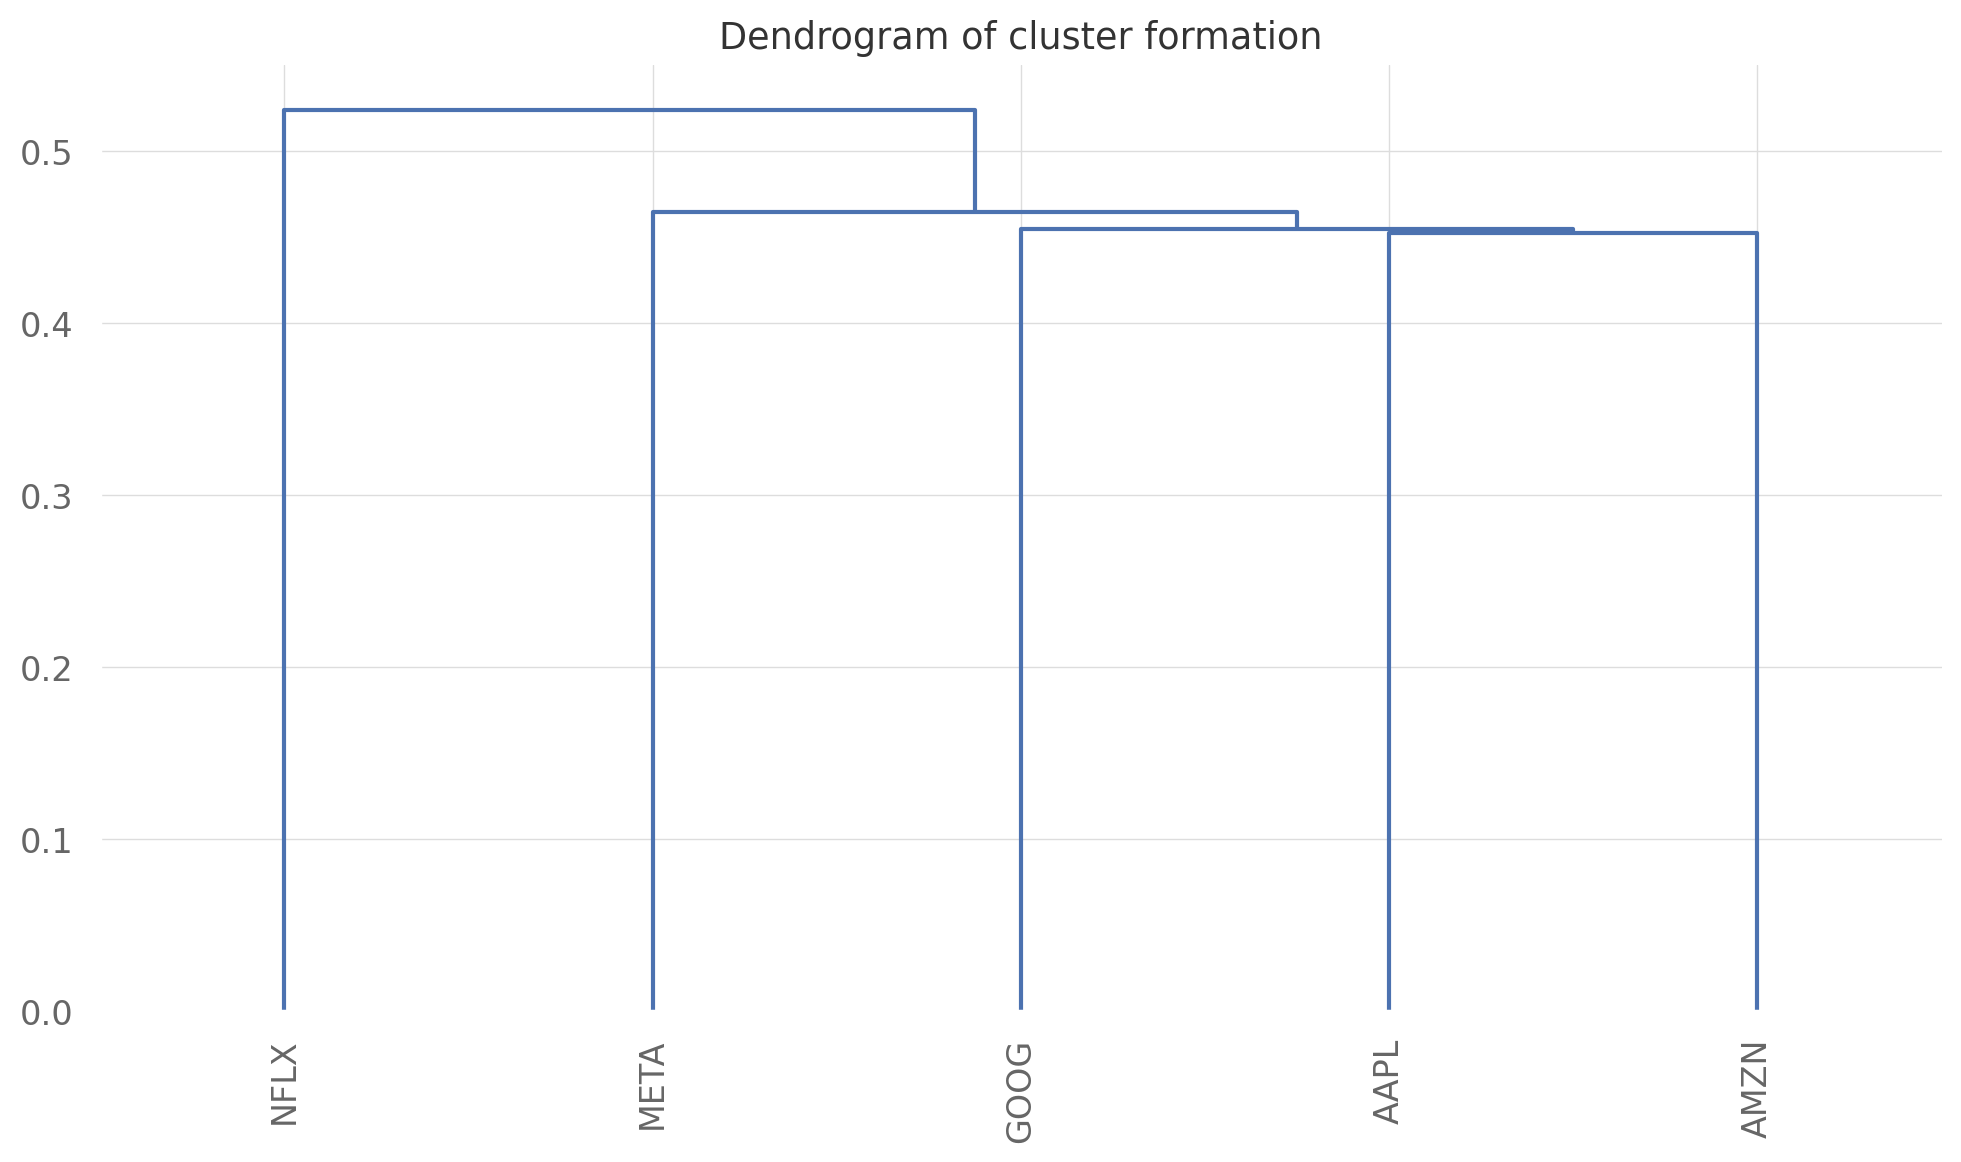

In [56]:
# Visualize the hierarchical clustering used for finding the portfolio weights:
fig, ax = plt.subplots()
plotting.plot_dendrogram(hrp, ax=ax)
ax.set_title("Dendrogram of cluster formation")

sns.despine()
plt.tight_layout()
# plt.savefig("images/figure_11_18", dpi=200)

In [57]:
latest_prices = get_latest_prices(prices_df)
allocation_finder = DiscreteAllocation(weights,
                                       latest_prices,
                                       total_portfolio_value=50000)
allocation, leftover = allocation_finder.lp_portfolio()
print(allocation)
print(leftover)


SolverError: The solver ECOS_BB is not installed.

In [58]:
# an alternative allocation using the greedy iterative algorithm
allocation, leftover = allocation_finder.greedy_portfolio()
print(allocation)
print(leftover)

{'GOOG': 96, 'META': 30, 'NFLX': 15, 'AMZN': 51, 'AAPL': 45}
139.1544189453125


In [59]:
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.plotting import plot_efficient_frontier

In [60]:
# Get the expected returns and the covariance matrix:
mu = mean_historical_return(prices_df)
S = CovarianceShrinkage(prices_df).ledoit_wolf()

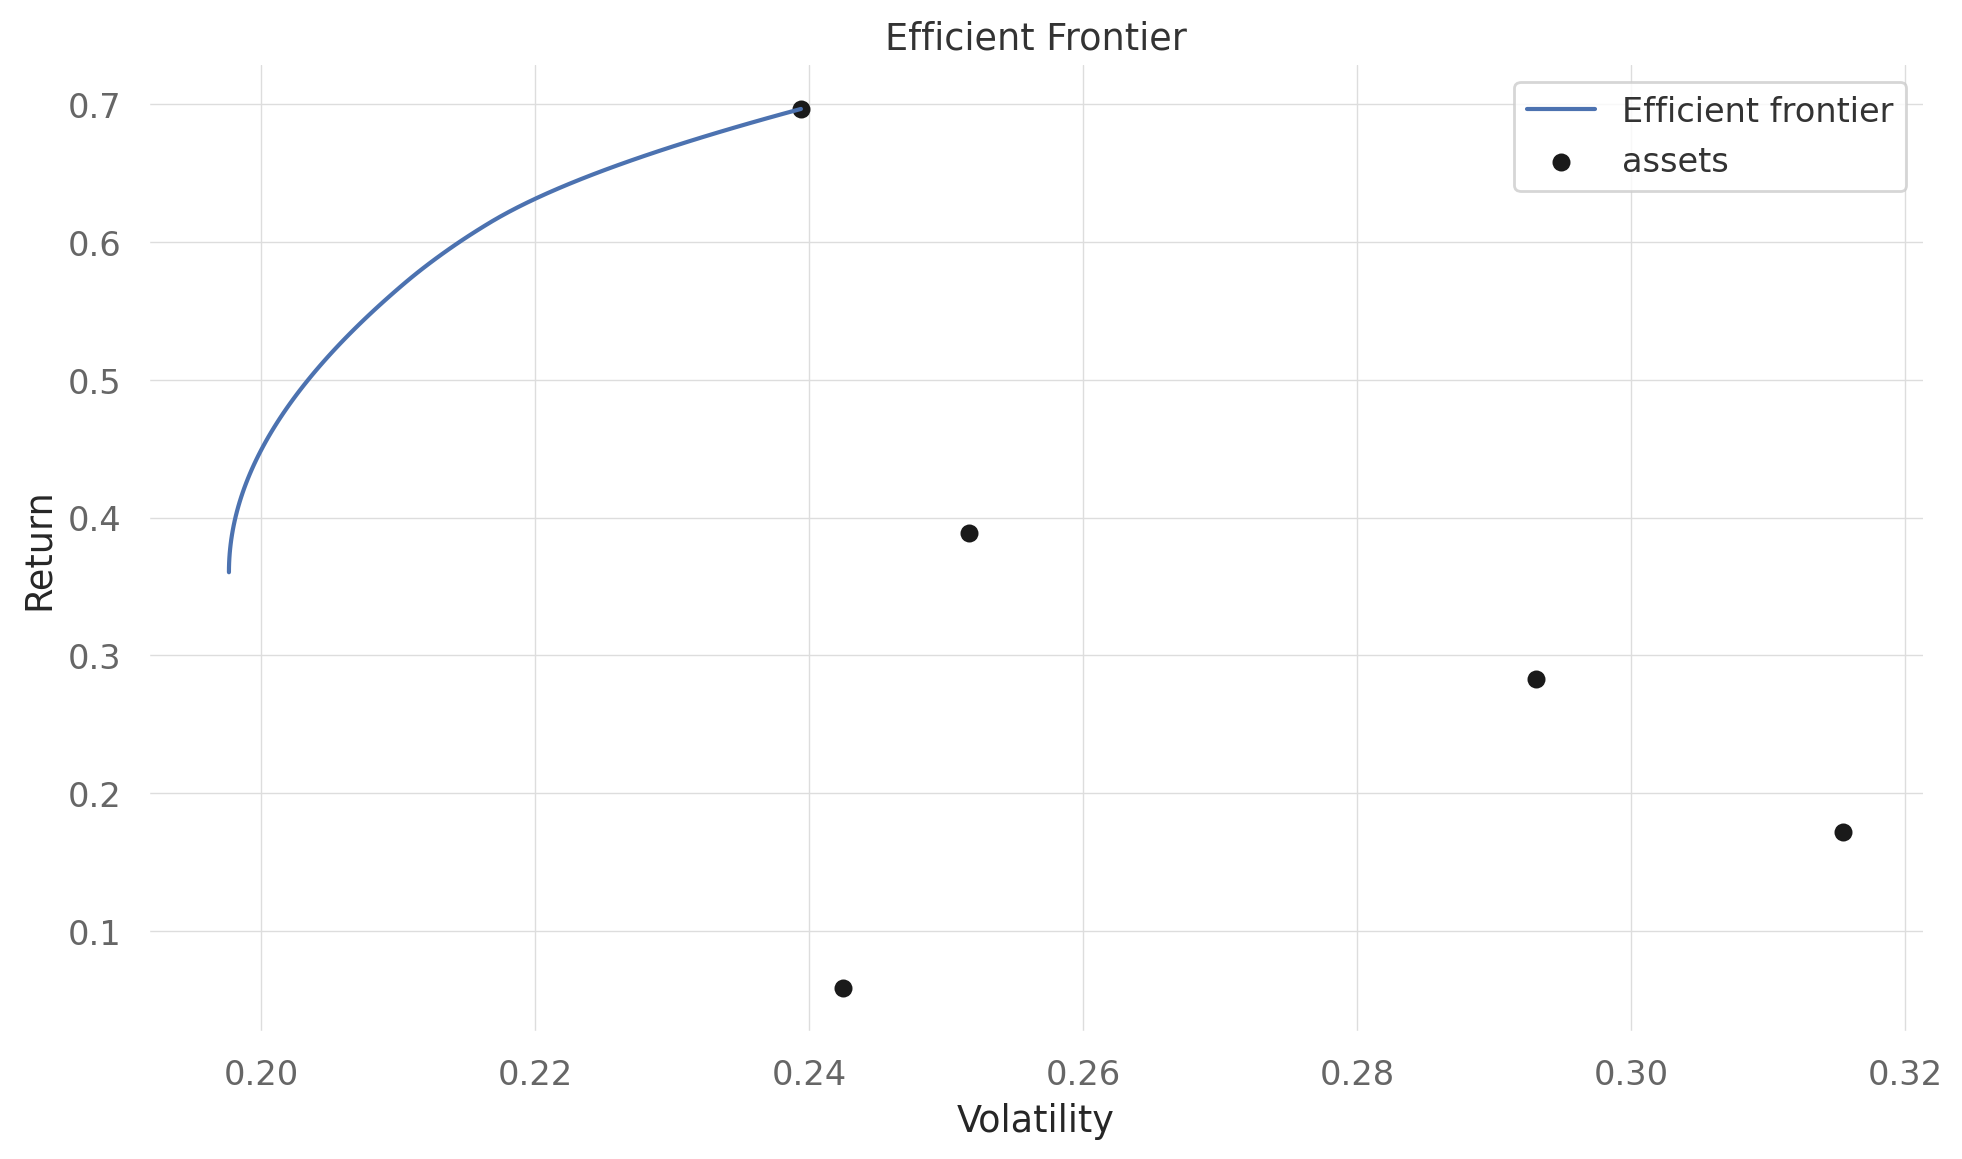

In [61]:
# Find and plot the Efficient Frontier:
ef = EfficientFrontier(mu, S)

fig, ax = plt.subplots()
plot_efficient_frontier(ef, ax=ax, show_assets=True)
ax.set_title("Efficient Frontier")


sns.despine()
plt.tight_layout()
# plt.savefig("images/figure_11_19", dpi=200)

In [62]:
# Identify the tangency portfolio:
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe(risk_free_rate=0)
print(ef.clean_weights())

OrderedDict([('AAPL', 0.04491), ('AMZN', 0.0), ('GOOG', 0.95509), ('META', 0.0), ('NFLX', 0.0)])


In [63]:
ef.portfolio_performance(verbose=True, risk_free_rate=0);

Expected annual return: 68.3%
Annual volatility: 23.4%
Sharpe Ratio: 2.91


In [64]:
# We get a warning when we are trying to use a different risk-free rate as the one used for finding the tangency portfolio.

ef.portfolio_performance(verbose=True);

Expected annual return: 68.3%
Annual volatility: 23.4%
Sharpe Ratio: 2.91


In [65]:
# Add L2 regularization to the portfolio optimization problem:
from pypfopt import objective_functions

ef = EfficientFrontier(mu, S)
ef.add_objective(objective_functions.L2_reg, gamma=0.2)

weights = ef.max_sharpe(risk_free_rate=0)
print(ef.clean_weights())

OrderedDict([('AAPL', 0.2611), ('AMZN', 0.0), ('GOOG', 0.58372), ('META', 0.12188), ('NFLX', 0.0333)])


/usr/local/lib/python3.11/dist-packages/pypfopt/efficient_frontier/efficient_frontier.py:259: UserWarning: max_sharpe transforms the optimization problem so additional objectives may not work as expected.
  warnings.warn(


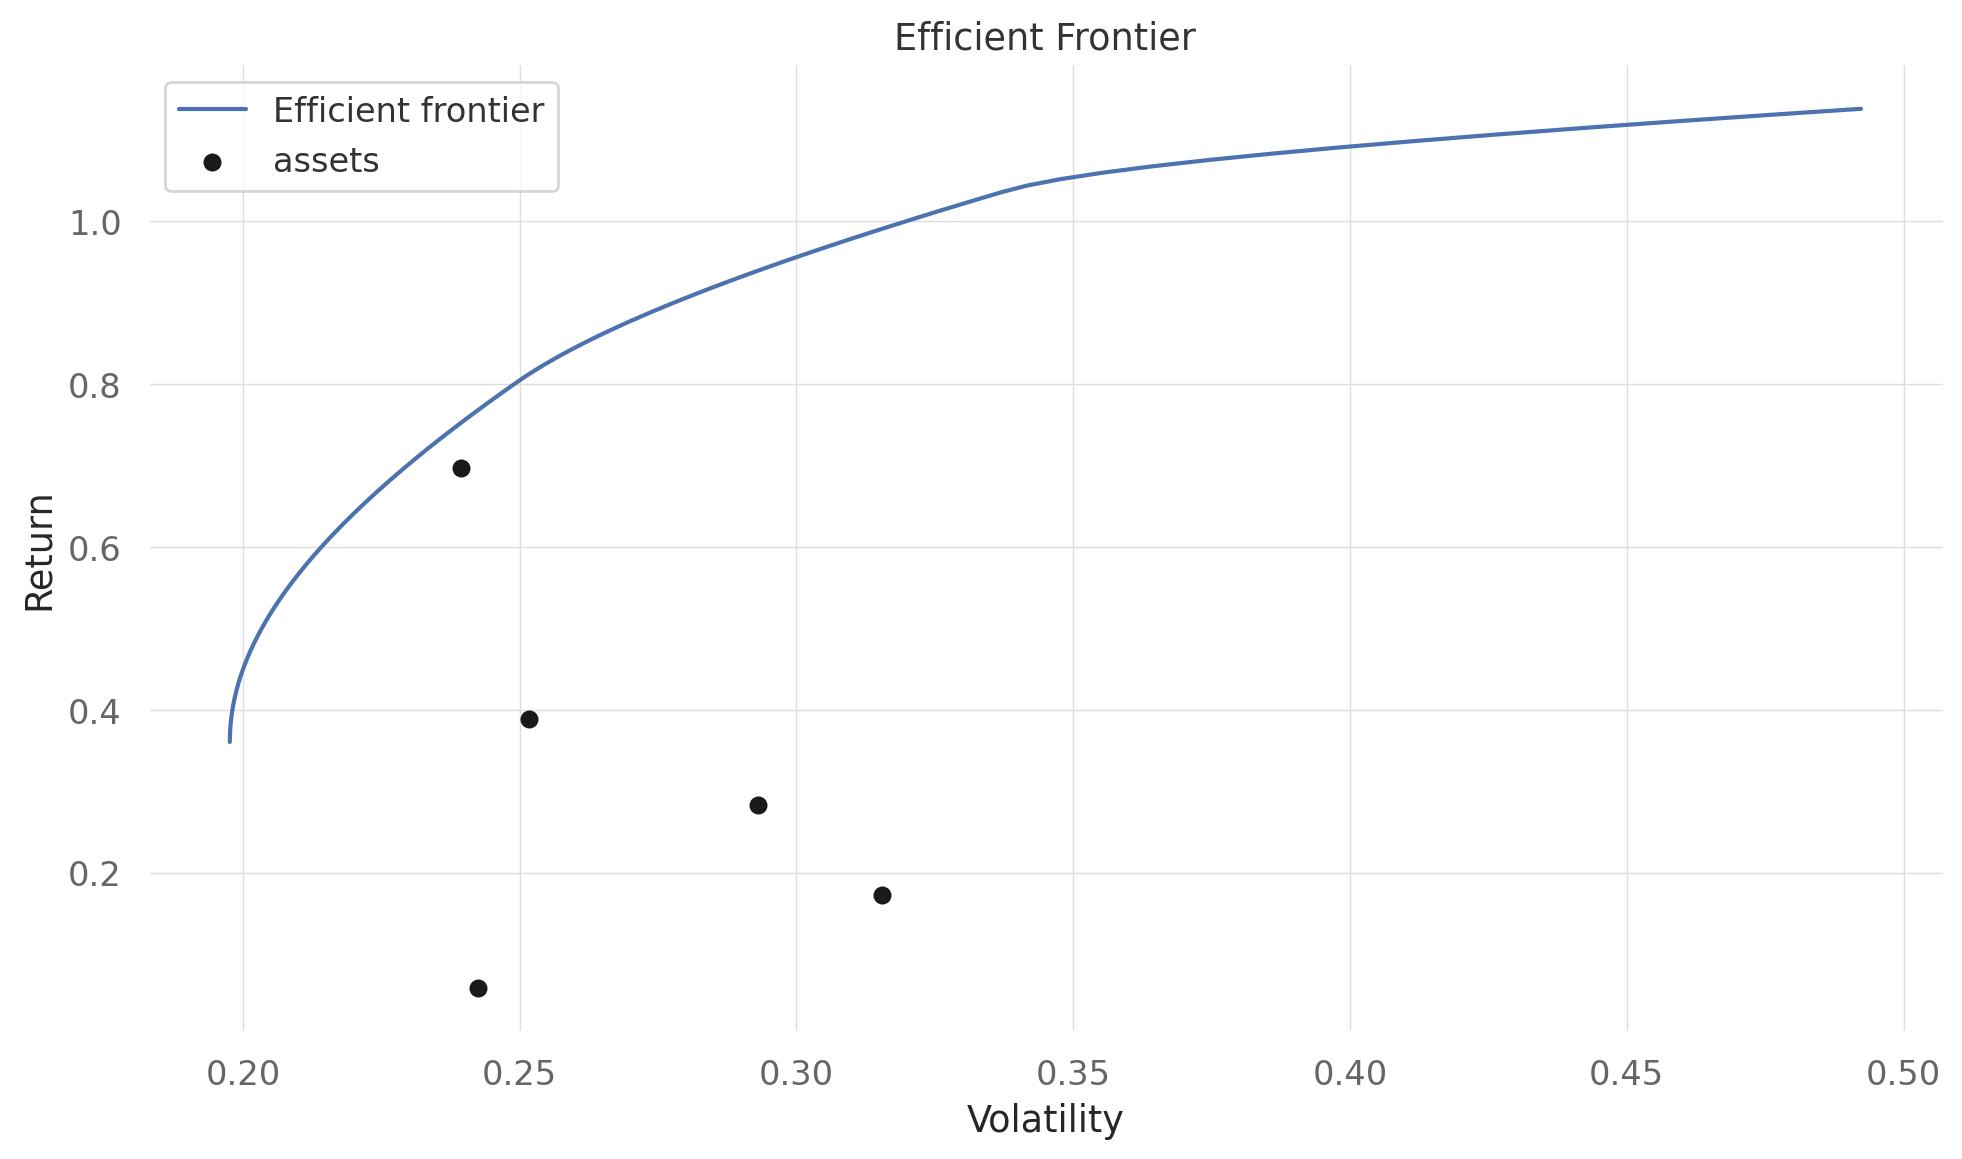

In [66]:
# Find the tangency portfolio with short-selling allowed:
ef = EfficientFrontier(mu, S, weight_bounds=(-1,1))

fig, ax = plt.subplots()
plot_efficient_frontier(ef, ax=ax, show_assets=True)
ax.set_title("Efficient Frontier")


sns.despine()
plt.tight_layout()

In [67]:
ef = EfficientFrontier(mu, S, weight_bounds=(-1,1))
weights = ef.max_sharpe(risk_free_rate=0)
print(ef.clean_weights())

OrderedDict([('AAPL', 0.51172), ('AMZN', -0.47136), ('GOOG', 1.0), ('META', -0.00344), ('NFLX', -0.03692)])


In [68]:
ef.portfolio_performance(verbose=True, risk_free_rate=0);

Expected annual return: 86.1%
Annual volatility: 26.5%
Sharpe Ratio: 3.25


## Backtest

In [69]:
!pip install pyfolio
import pyfolio as pf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.8 MB/s eta 0:00:00
  Created wheel for pyfolio: filename=pyfolio-0.9.2-py3-none-any.whl size=88654 sha256=cb166b204ada7ccc364821f4d11371cafdd24359935294dbd88e077351de61cf
  Stored in directory: /root/.cache/pip/wheels/f9/af/9e/7c343b822164a3147a3d395a1bcd05041c520a3bc6398fe88e
  Created wheel for empyrical: filename=empyrical-0.5.5-py3-none-any.whl size=39752 sha256=aff0a925114bcbc88a27ebd9ffaed2967c2c86074301877b17298ec7f9fed394
  Stored in directory: /root/.cache/pip/wheels/ac/1d/58/a7ae5ef5c8de7c4b769f24c2584f4706564921f031b16b9cb6
Successfully built pyfolio empyrical


/usr/local/lib/python3.11/dist-packages/pyfolio/pos.py:26: UserWarning: Module "zipline.assets" not found; mutltipliers will not be applied to position notionals.
  warnings.warn(


In [70]:
# Set up the parameters:
RISKY_ASSETS = ["META", "AMZN", "AAPL", "NFLX", "GOOG"]
START_DATE = "2020-01-01"
END_DATE = "2021-12-31"

n_assets = len(RISKY_ASSETS)

[*********************100%***********************]  5 of 5 completed


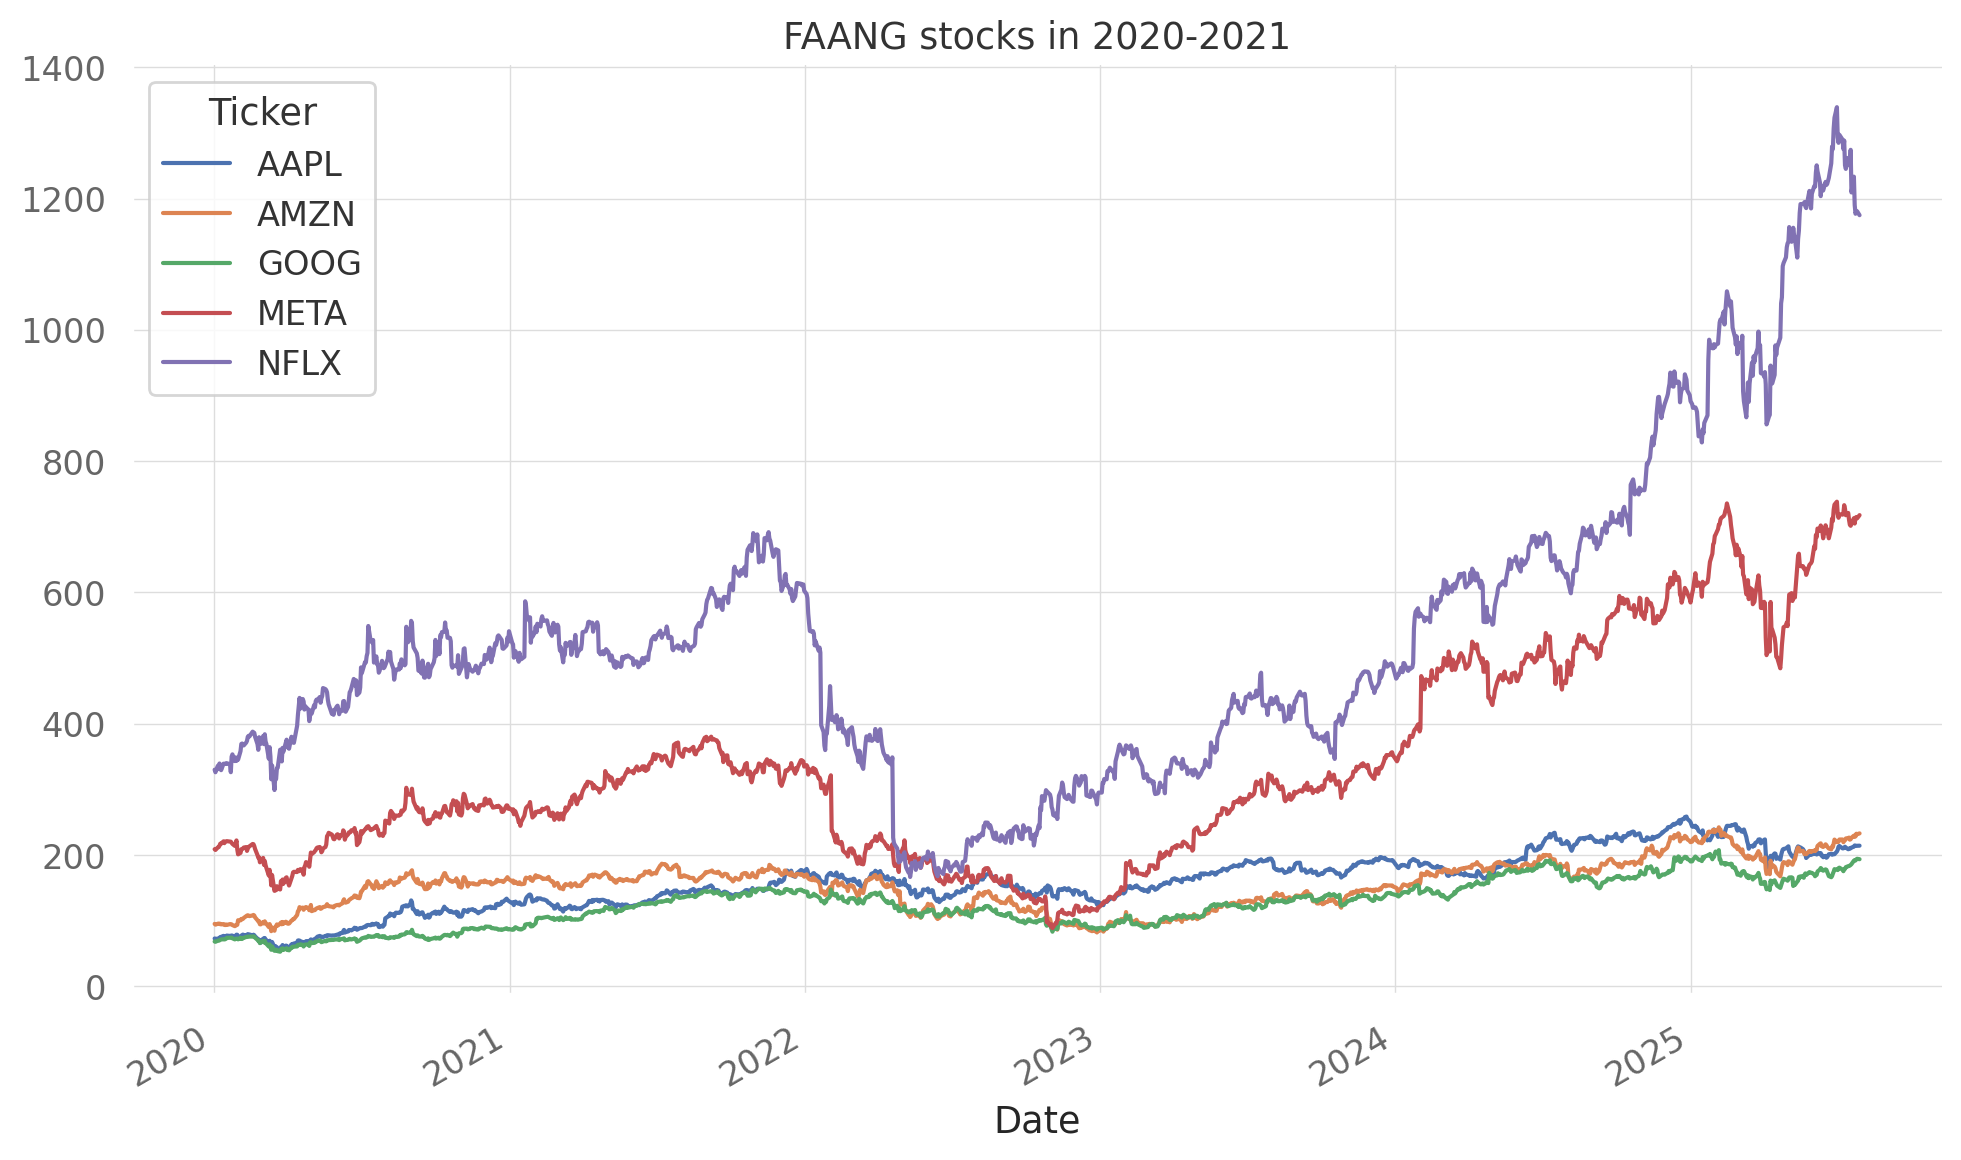

In [71]:
# Download the stock prices from Yahoo Finance:
prices_df = yf.download(RISKY_ASSETS, start=START_DATE)
prices_df["Close"].plot(title="FAANG stocks in 2020-2021");

sns.despine()
plt.tight_layout()

In [72]:
# Calculate individual asset returns:
returns = prices_df["Close"].pct_change().dropna()

In [73]:
# Define the weights (Equipondéré):
portfolio_weights = n_assets * [1 / n_assets]

In [74]:
portfolio_weights

[0.2, 0.2, 0.2, 0.2, 0.2]

In [75]:
# Calculate portfolio returns:
portfolio_returns = pd.Series(np.dot(portfolio_weights, returns.T),
                              index=returns.index)

In [76]:
# Create the tear sheet (simple variant):

qs.reports.html(portfolio_returns,
                title="Mon portefeuille optimisé",
                output="report.html",
                benchmark="^GSPC")  # benchmark = S&P 500 par défaut

In [77]:
qs.reports.metrics(portfolio_returns, benchmark="^GSPC")

                     Benchmark (^GSPC)    Strategy
-------------------  -------------------  ----------
Start Period         2020-01-03           2020-01-03
End Period           2025-07-28           2025-07-28
Risk-Free Rate       0.0%                 0.0%
Time in Market       100.0%               100.0%

Cumulative Return    97.53%               255.41%
CAGR﹪               8.8%                 17.02%

Sharpe               0.68                 0.9
Prob. Sharpe Ratio   94.33%               98.24%
Sortino              0.96                 1.29
Sortino/√2           0.68                 0.91
Omega                1.17                 1.17

Max Drawdown         -33.92%              -49.94%
Max DD Date          2020-03-23           2022-11-03
Max DD Period Start  2020-02-20           2021-11-22
Max DD Period End    2020-08-17           2023-12-15
Longest DD Days      745                  754

Gain/Pain Ratio      0.14                 0.17
Gain/Pain (1M)       0.79                 1.2

Payoff 

In [78]:
import quantstats as qs
from IPython.display import display, HTML
import tempfile

# Générer le rapport dans un fichier temporaire
with tempfile.NamedTemporaryFile(suffix=".html", delete=False) as f:
    temp_filename = f.name

qs.reports.html(portfolio_returns,
                title="Mon portefeuille optimisé",
                output=temp_filename,
                benchmark="^GSPC")

# Lire le contenu HTML
with open(temp_filename, "r", encoding="utf-8") as file:
    html_content = file.read()

# Afficher directement dans la cellule Colab
display(HTML(html_content))


[*********************100%***********************]  1 of 1 completed


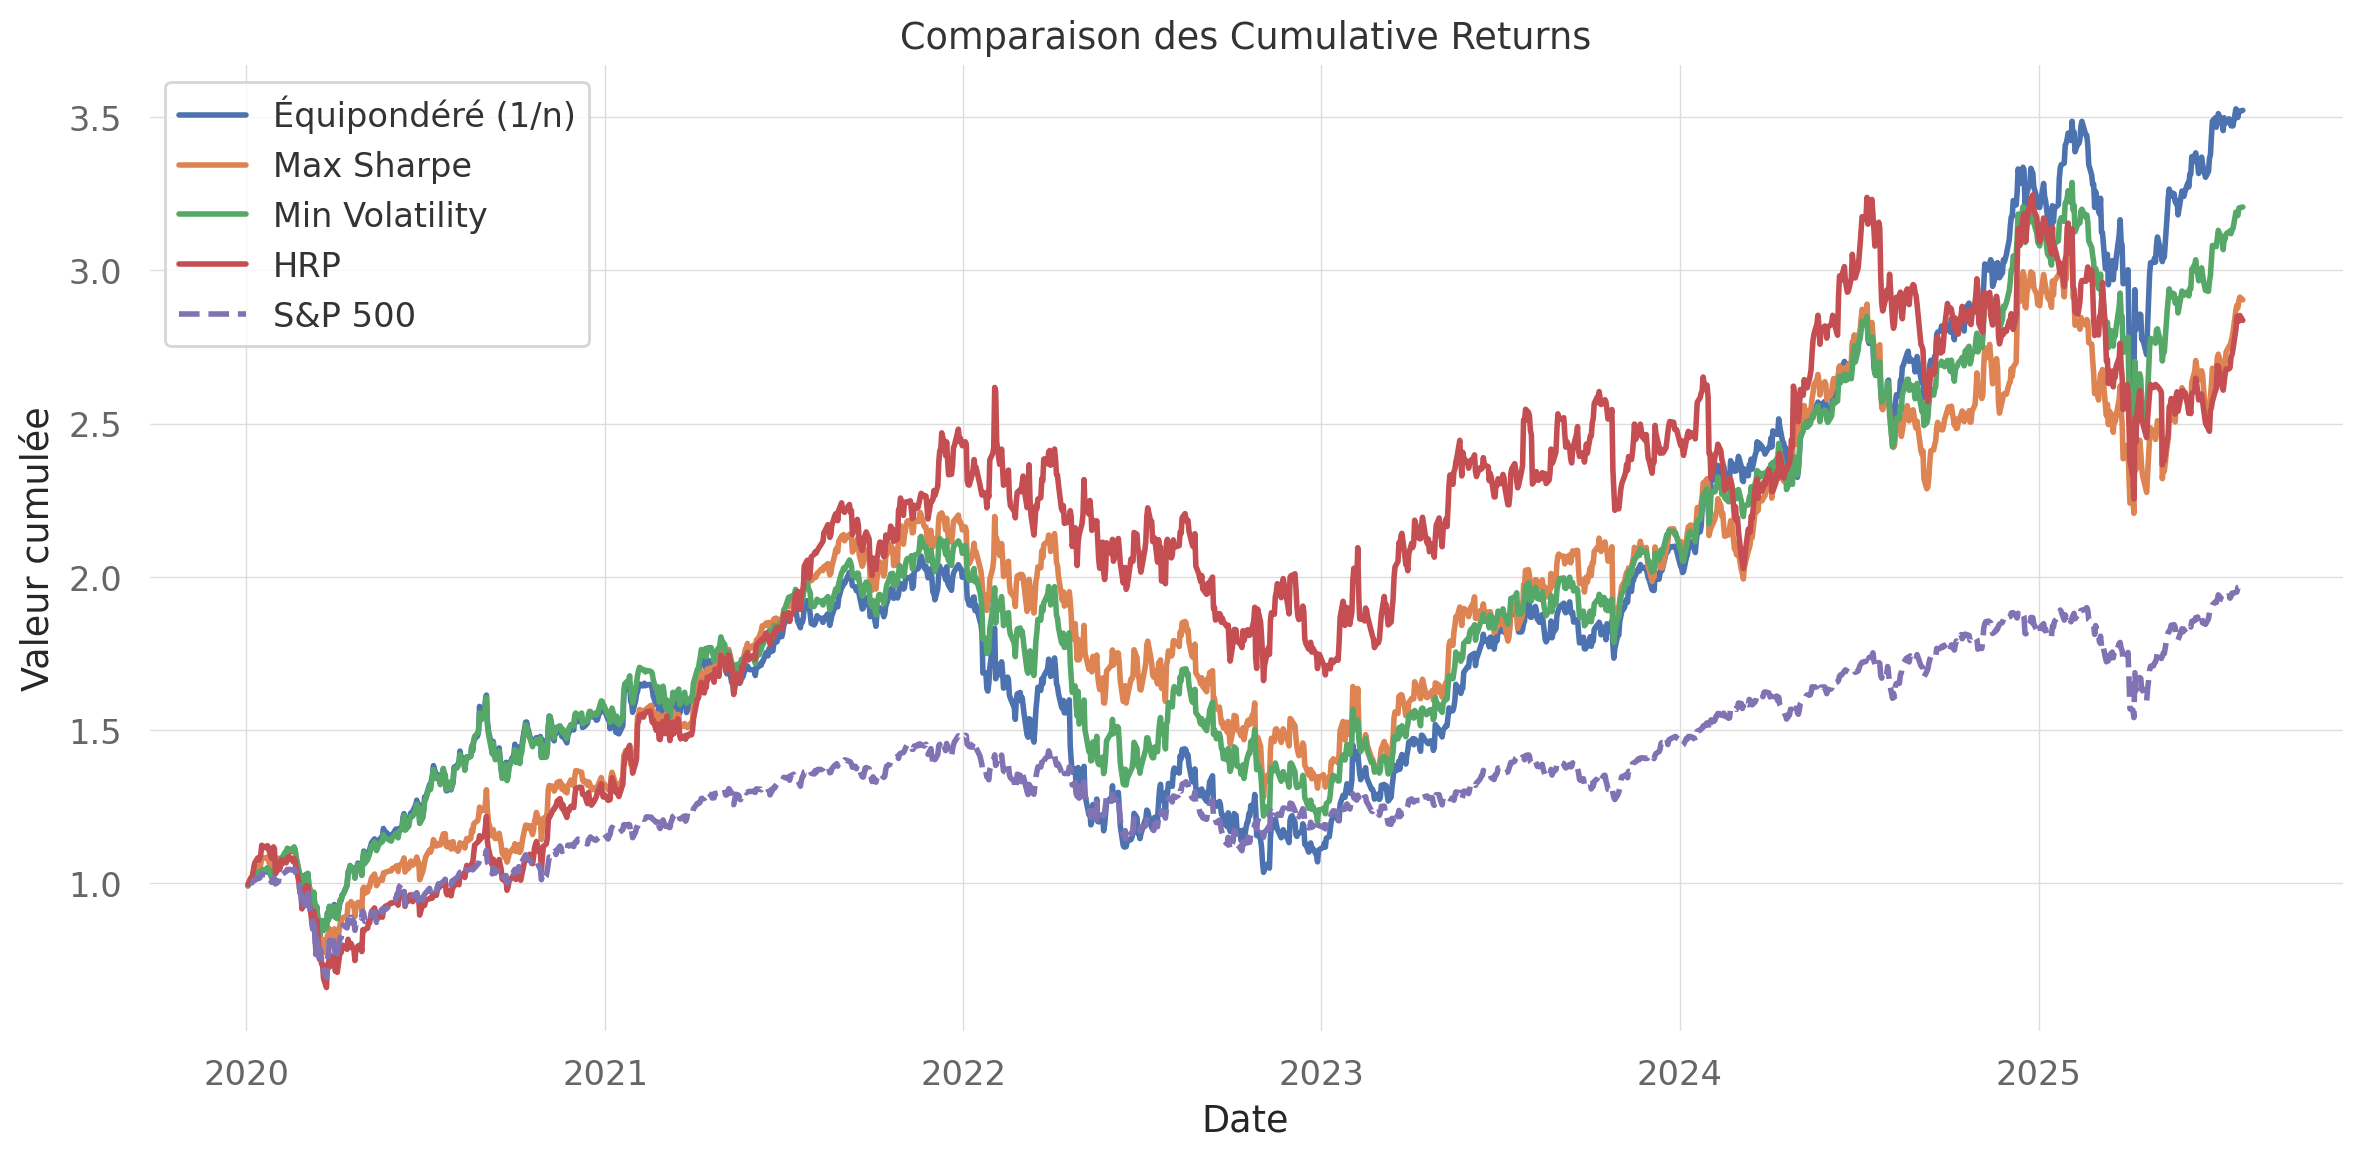

In [79]:
# 1. Calcul des retours cumulés pour différents portefeuilles

# Retour équipondéré
weights_equal = np.array([1/n_assets] * n_assets)
returns_equal = returns @ weights_equal
cumulative_equal = (1 + returns_equal).cumprod()

# Portefeuille max Sharpe (déjà extrait avec scipy ou pypfopt)
returns_max_sharpe = returns @ max_sharpe_portf_w
cumulative_max_sharpe = (1 + returns_max_sharpe).cumprod()

# Portefeuille min volatilité
returns_min_vol = returns @ efficient_portfolios[min_vol_ind]["x"]
cumulative_min_vol = (1 + returns_min_vol).cumprod()

# Portefeuille HRP (via pypfopt)
hrp_weights = np.array([weights.get(asset, 0) for asset in ASSETS])
returns_hrp = returns[ASSETS] @ hrp_weights
cumulative_hrp = (1 + returns_hrp).cumprod()

# Benchmark (ex : S&P 500)
benchmark_df = yf.download("^GSPC", start=returns.index.min(), end=returns.index.max())["Close"]
benchmark_returns = benchmark_df.pct_change().dropna()
cumulative_benchmark = (1 + benchmark_returns).cumprod()
# Aligner le benchmark sur les dates de l'équipondéré
cumulative_benchmark = cumulative_benchmark.reindex(cumulative_equal.index).fillna(method="ffill")


# 2. Tracer tous les cumulés
plt.figure(figsize=(12, 6))
plt.plot(cumulative_equal, label="Équipondéré (1/n)", linewidth=2)
plt.plot(cumulative_max_sharpe, label="Max Sharpe", linewidth=2)
plt.plot(cumulative_min_vol, label="Min Volatility", linewidth=2)
plt.plot(cumulative_hrp, label="HRP", linewidth=2)
plt.plot(cumulative_benchmark, label="S&P 500", linestyle="--", linewidth=2)

plt.title("Comparaison des Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Valeur cumulée")
plt.legend()
sns.despine()
plt.tight_layout()
plt.grid(True)
plt.show()
